# Deepfake Audio Detection
## Setup, Exploration & Feature Extraction

---
## Required Libraries

| Package | Purpose |
|---------|---------|
| `numpy` | Numerical computing — arrays, matrices, math operations on audio data |
| `librosa` | Audio analysis — loading `.flac` files, extracting MFCCs, Mel spectrograms, spectral features |
| `soundfile` | Backend for librosa to read audio file formats (FLAC, WAV) |
| `scikit-learn` | Classical ML models — Logistic Regression, SVM, StandardScaler, evaluation metrics |
| `torch` | PyTorch deep learning framework — building and training the CNN |
| `torchaudio` | Audio processing utilities for PyTorch |
| `matplotlib` | Plotting — waveforms, spectrograms, training curves, bar charts |
| `seaborn` | Statistical visualization — confusion matrix heatmaps |
| `pandas` | Data manipulation — parsing protocol files into DataFrames |
| `tqdm` | Progress bars — shows extraction/training progress |
| `joblib` | Model serialization — saving/loading trained sklearn models |

In [133]:
!pip3 install numpy librosa soundfile scikit-learn torch torchaudio matplotlib seaborn pandas tqdm joblib
!pip3 install transformers

Python(4653) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Python(4728) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 12.0 MB 4.9 MB/s eta 0:00:01
     |████████████████████████████████| 447 kB 7.8 MB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 10.4 MB/s eta 0:00:01
     |████████████████████████████████| 566 kB 7.3 MB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 11.1 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [16]:
import os, sys, zipfile, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
from tqdm.notebook import tqdm
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports OK')

Imports OK



## Configuration

### Dataset Paths
- **DATASET_ZIP** — Path to the downloaded ASVspoof 2019 LA dataset zip file
- **EXTRACT_DIR** — Directory where the zip will be extracted
- **DATASET_ROOT** — Root of the LA dataset (contains audio folders and protocol files)
- **TRAIN/DEV/EVAL_AUDIO** — Directories containing `.flac` audio files for each split
- **PROTO_DIR** — Directory containing protocol (label) files that map each audio file to bonafide/spoof

### Audio Processing Parameters
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `SR` | 16,000 | Sample rate in Hz — 16,000 snapshots of the sound wave per second (standard for speech) |
| `DUR` | 4.0 | Duration in seconds — each clip is padded/trimmed to exactly 4 seconds |
| `MAX_SAMP` | 64,000 | Total samples per clip = SR × DUR = 16,000 × 4 |

### Feature Extraction Parameters
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `N_MFCC` | 20 | Number of MFCC coefficients to extract per frame |
| `N_FFT` | 512 | FFT window size (~32ms at 16kHz) — controls frequency resolution |
| `HOP` | 256 | Hop length between frames (~16ms) — controls time resolution |
| `N_MELS` | 128 | Number of Mel frequency bands for spectrograms |
| `MEL_T` | 251 | Fixed time dimension for Mel spectrograms (from 64,000 samples / 256 hop) |

### Other
- **MAX_N** — Set to `None` for full dataset, or an integer (e.g., 2000) for quick testing with fewer samples
- **FEAT_DIR** — Directory where extracted features will be saved as `.npz` files


In [119]:
# ===== CONFIGURATION =====
DATASET_ZIP  = '/Users/pobbamk/ASVspoof2019LAdataset.zip'
EXTRACT_DIR  = '/Users/pobbamk/ASVspoof2019'
DATASET_ROOT = os.path.join(EXTRACT_DIR, 'LA', 'LA')
TRAIN_AUDIO  = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_train', 'flac')
DEV_AUDIO    = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_dev', 'flac')
EVAL_AUDIO   = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_eval', 'flac')
PROTO_DIR    = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_cm_protocols')
TRAIN_PROTO  = os.path.join(PROTO_DIR, 'ASVspoof2019.LA.cm.train.trn.txt')
DEV_PROTO    = os.path.join(PROTO_DIR, 'ASVspoof2019.LA.cm.dev.trl.txt')
EVAL_PROTO   = os.path.join(PROTO_DIR, 'ASVspoof2019.LA.cm.eval.trl.txt')
SR = 16000; DUR = 4.0; MAX_SAMP = int(SR*DUR)
N_MFCC=20; N_FFT=512; HOP=256; N_MELS=128; MEL_T=251
MAX_N = None  # Set to int (e.g. 5000) for quick test
FEAT_DIR = os.path.join(os.path.dirname(EXTRACT_DIR), 'features')
os.makedirs(FEAT_DIR, exist_ok=True)
print('Config OK')

Config OK


## Dataset Extraction

This cell extracts the ASVspoof 2019 LA dataset from the downloaded `.zip` file.

- **First run:** Unzips the dataset to `EXTRACT_DIR` (takes a few minutes for ~5GB)
- **Subsequent runs:** Detects the extracted folder already exists and skips extraction
- **Prints** the contents of the dataset root folder to verify the structure

### Expected folder structure after extraction:

### ASVspoof2019/LA/LA/ 
* ASVspoof2019_LA_train/flac/ ← 25,380 training audio files 
* ASVspoof2019_LA_dev/flac/ ← 24,844 development audio files 
* ASVspoof2019_LA_eval/flac/ ← 71,237 evaluation audio files 
* ASVspoof2019_LA_cm_protocols/ ← Protocol (label) files 
* ASVspoof2019_LA_asv_protocols/ ← ASV protocol files (not used) 
* ASVspoof2019_LA_asv_scores/ ← ASV scores (not used)



In [120]:
# ===== unzip DATASET =====
if not os.path.exists(DATASET_ROOT):
    print(f'Extracting {DATASET_ZIP}...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Done!')
else:
    print(f'Already extracted at {DATASET_ROOT}')
for x in sorted(os.listdir(DATASET_ROOT)): print(f'  {x}')

Already extracted at /Users/pobbamk/ASVspoof2019/LA/LA
  .DS_Store
  ASVspoof2019_LA_asv_protocols
  ASVspoof2019_LA_asv_scores
  ASVspoof2019_LA_cm_protocols
  ASVspoof2019_LA_dev
  ASVspoof2019_LA_eval
  ASVspoof2019_LA_train
  README.LA.txt


## Parse Protocol Files (Ground Truth Labels)

Protocol files are plain text files that serve as the **answer key** for the dataset — they tell us which audio file is real and which is AI-generated.

### Protocol file format (space-separated):

LA_0079 LA_T_1000137 - A04 spoof LA_0079 LA_T_1000265 - - bonafide p[0] p[1] p[2] p[3] p[4] | | | | | Speaker Filename sep Attack Label ID System (real/fake)



### What the function does:
1. Reads each line of the protocol file
2. Splits into columns: `speaker`, `filename`, `system` (attack type), `key` (bonafide/spoof)
3. Converts `key` to numeric label: **0 = bonafide (real)**, **1 = spoof (fake)**
4. Returns a pandas DataFrame for easy filtering and analysis

### Three protocol files:
| File | Split | Purpose |
|------|-------|---------|
| `train.trn.txt` | Training | Model learns from these (A01–A06 attacks) |
| `dev.trl.txt` | Development | Validation during training (A01–A06 attacks) |
| `eval.trl.txt` | Evaluation | Final testing (A07–A19 unseen attacks) |

In [121]:
# ===== PARSE PROTOCOLS =====
def parse_proto(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.strip().split()
            if len(p)>=5:
                rows.append({'speaker':p[0],'filename':p[1],'system':p[2],
                             'key':p[4],'label':0 if p[4]=='bonafide' else 1})
    return pd.DataFrame(rows)

df_tr = parse_proto(TRAIN_PROTO)
df_dv = parse_proto(DEV_PROTO)
df_ev = parse_proto(EVAL_PROTO)
for n,d in [('Train',df_tr),('Dev',df_dv),('Eval',df_ev)]:
    print(f'{n}: {len(d)} total, {(d.key=="bonafide").sum()} bon, {(d.key=="spoof").sum()} spf')

Train: 25380 total, 2580 bon, 22800 spf
Dev: 24844 total, 2548 bon, 22296 spf
Eval: 71237 total, 7355 bon, 63882 spf


## Class Distribution Visualization

This chart shows the number of **bonafide (real)** vs **spoof (fake)** audio samples in each data split.

### Key observation: Heavy class imbalance
- Spoof samples outnumber bonafide by roughly **9:1**
- This reflects reality — an attacker can generate unlimited fake audio, but genuine recordings are limited

| Split | Bonafide | Spoof | Ratio |
|-------|----------|-------|-------|
| Train | 2,580 | 22,800 | 1:8.8 |
| Dev | 2,548 | 22,296 | 1:8.7 |
| Eval | 7,355 | 63,882 | 1:8.7 |

### Why this matters for ML:
Without handling imbalance, a model could predict **"spoof" for everything** and still get ~90% accuracy — but it would miss all real speech. We address this using:
- **`class_weight='balanced'`** in Logistic Regression and SVM — gives more importance to the minority class (bonafide)
- **Weighted `CrossEntropyLoss`** in CNN — penalizes mistakes on bonafide samples more heavily
- **Evaluation metrics beyond accuracy** — we focus on Recall, F1, and confusion matrix rather than accuracy alone

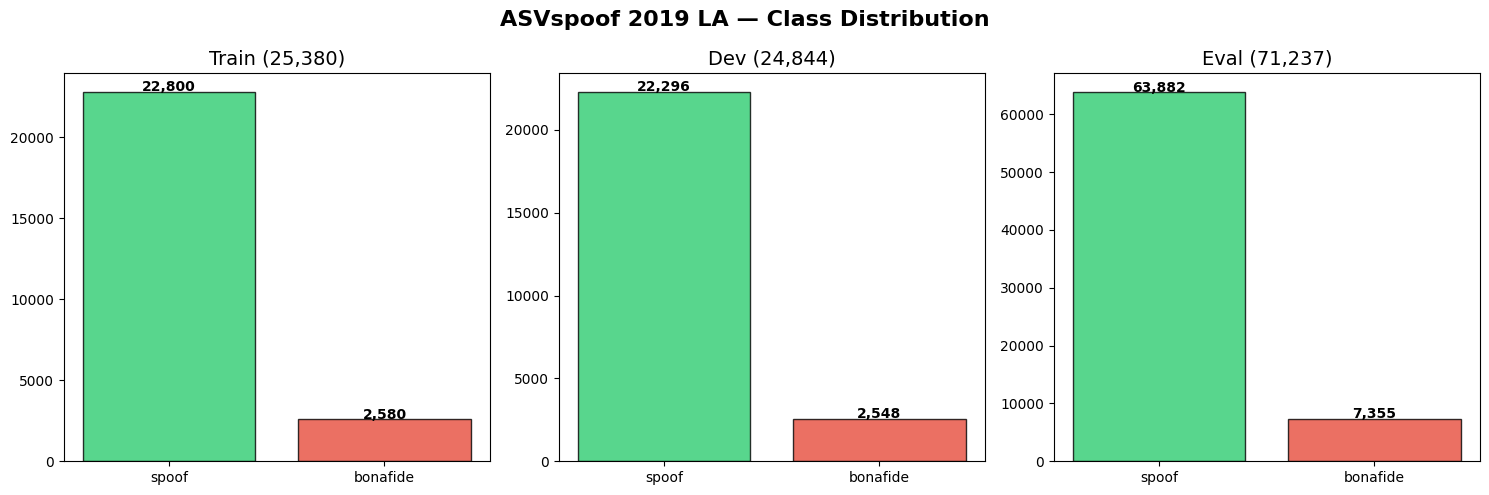

In [122]:
# ===== CLASS DISTRIBUTION =====
fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax,(n,d) in zip(axes,[('Train',df_tr),('Dev',df_dv),('Eval',df_ev)]):
    c = d.key.value_counts()
    ax.bar(c.index, c.values, color=['#2ecc71','#e74c3c'], alpha=.8, edgecolor='k')
    ax.set_title(f'{n} ({len(d):,})', fontsize=14)
    for b,v in zip(ax.patches, c.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('ASVspoof 2019 LA — Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

### 1. `load_audio(filepath)` — Load and normalize audio
Converts a `.flac` audio file into a fixed-length array of numbers:
1. **Load** at 16,000 Hz sample rate using librosa
2. **Normalize** amplitude to [-1, 1] by dividing by the maximum absolute value
3. **Pad** with zeros if shorter than 4 seconds, or **truncate** if longer
4. **Output:** array of exactly 64,000 float32 numbers

### 2. `extract_hc(audio)` — Hand-crafted features (70-dim vector)
Extracts a compact numerical summary for classical ML models:

| Feature | Count | What it captures |
|---------|-------|------------------|
| MFCC means | 20 | Average shape of the vocal tract (pitch, timbre) |
| MFCC stds | 20 | How much the vocal tract shape varies over time |
| MFCC delta means | 20 | Rate of change of vocal characteristics |
| Spectral centroid (mean, std) | 2 | "Brightness" — where the center of mass of the spectrum is |
| Spectral rolloff (mean, std) | 2 | Frequency below which 85% of energy is concentrated |
| Zero crossing rate (mean, std) | 2 | How often the signal crosses zero — indicates noisiness |
| Spectral bandwidth (mean, std) | 2 | How spread out the frequency content is |
| RMS energy (mean, std) | 2 | Overall loudness of the signal |
| **Total** | **70** | |

### 3. `extract_mel(audio)` — Mel spectrogram (128 × 251 image)
Creates a 2D "picture" of the audio for the CNN:
- **Y-axis:** 128 Mel frequency bands (low to high pitch)
- **X-axis:** 251 time frames (0 to 4 seconds)
- **Pixel value:** Energy in decibels (−80 dB = silence, 0 dB = loudest)
- Converted to log-scale (dB) to match human perception of loudness

In [123]:
# ===== AUDIO HELPERS =====
def load_audio(fp):
    try: a,_ = librosa.load(fp, sr=SR, mono=True)
    except: return np.zeros(MAX_SAMP, dtype=np.float32)
    mx = np.max(np.abs(a))
    if mx>0: a = a/mx
    if len(a)<MAX_SAMP: a = np.pad(a,(0,MAX_SAMP-len(a)))
    else: a = a[:MAX_SAMP]
    return a.astype(np.float32)

def extract_hc(a):
    f = []
    mc = librosa.feature.mfcc(y=a,sr=SR,n_mfcc=N_MFCC,n_fft=N_FFT,hop_length=HOP)
    f.extend(np.mean(mc,1)); f.extend(np.std(mc,1))
    f.extend(np.mean(librosa.feature.delta(mc),1))
    for fn in [librosa.feature.spectral_centroid, librosa.feature.spectral_rolloff]:
        v=fn(y=a,sr=SR,n_fft=N_FFT,hop_length=HOP)[0]; f.extend([np.mean(v),np.std(v)])
    for fn,kw in [(librosa.feature.zero_crossing_rate,{'frame_length':N_FFT,'hop_length':HOP}),
                  (librosa.feature.spectral_bandwidth,{'sr':SR,'n_fft':N_FFT,'hop_length':HOP}),
                  (librosa.feature.rms,{'frame_length':N_FFT,'hop_length':HOP})]:
        v=fn(y=a,**kw)[0]; f.extend([np.mean(v),np.std(v)])
    return np.array(f, dtype=np.float32)

def extract_mel(a):
    ms = librosa.power_to_db(librosa.feature.melspectrogram(y=a,sr=SR,n_fft=N_FFT,hop_length=HOP,n_mels=N_MELS),ref=np.max)
    if ms.shape[1]<MEL_T: ms=np.pad(ms,((0,0),(0,MEL_T-ms.shape[1])),constant_values=-80.)
    else: ms=ms[:,:MEL_T]
    return ms.astype(np.float32)

# Test
ta = load_audio(os.path.join(TRAIN_AUDIO, f'{df_tr.filename.iloc[0]}.flac'))
print(f'HC: {extract_hc(ta).shape}, Mel: {extract_mel(ta).shape}')

HC: (70,), Mel: (128, 251)


---
## Sample Audio Visualizations: Bonafide vs Spoof

This cell displays 3 bonafide (real) and 3 spoof (fake) audio samples in two formats:

### Row layout (4 rows × 3 columns):
- **Row 1:** Waveforms of 3 bonafide samples (green)
- **Row 2:** Mel spectrograms of those same 3 bonafide samples
- **Row 3:** Waveforms of 3 spoof samples (red)
- **Row 4:** Mel spectrograms of those same 3 spoof samples

### What to look for:
- **Waveforms:** Real speech typically shows irregular amplitude patterns with natural pauses. Spoof audio may appear smoother or more uniform.
- **Spectrograms:** Real speech has rich, varied frequency content with natural harmonics. Spoof audio from TTS systems often shows smoother spectral patterns, sharper frequency cutoffs, or missing high-frequency content — these are the artifacts our models learn to detect.

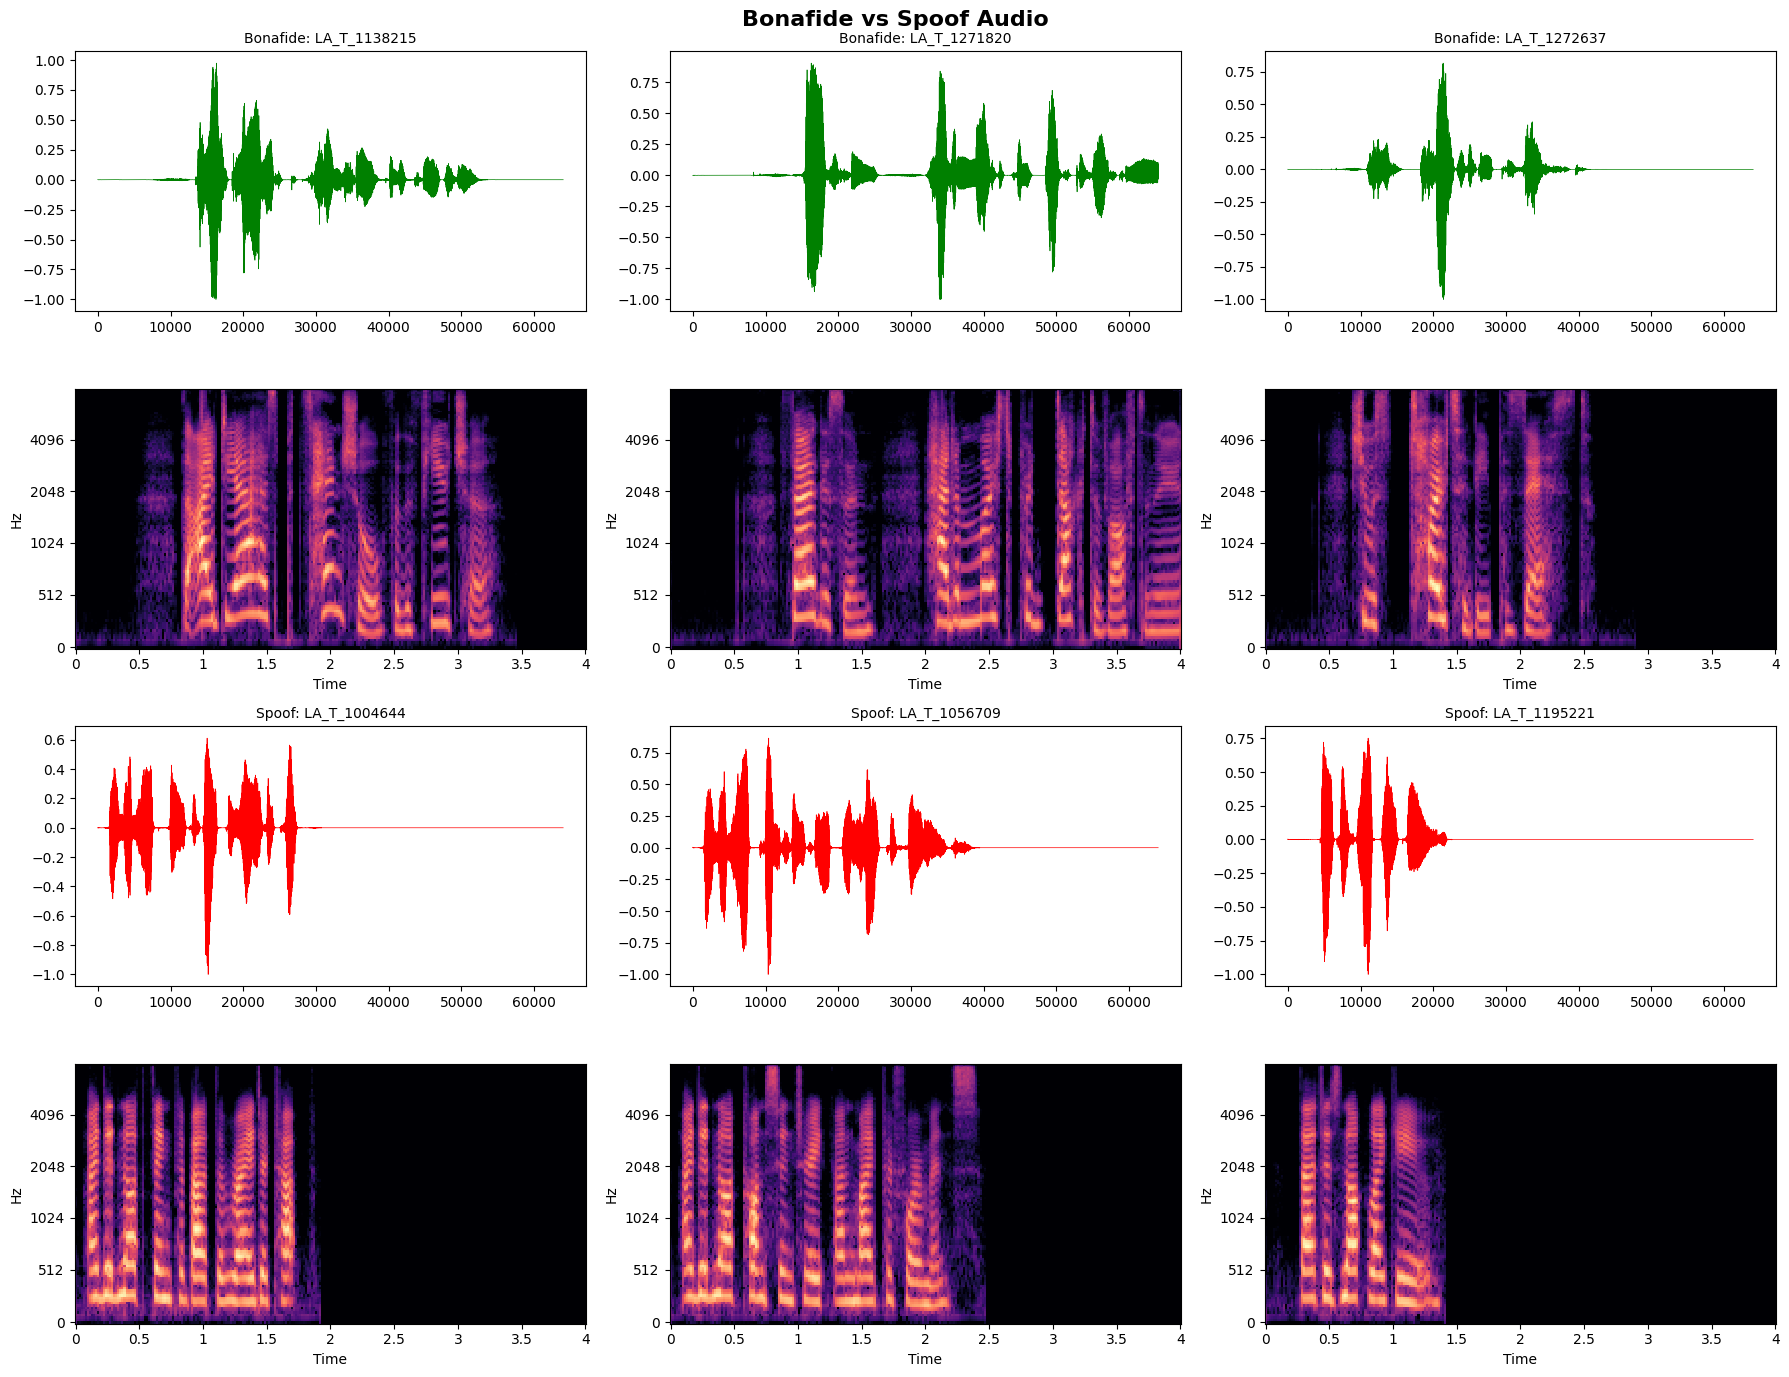

In [124]:
# ===== SAMPLE VISUALIZATIONS =====
fig,axes = plt.subplots(4,3,figsize=(18,14))
for i,fn in enumerate(df_tr[df_tr.key=='bonafide'].filename.values[:3]):
    a=load_audio(os.path.join(TRAIN_AUDIO,f'{fn}.flac'))
    axes[0,i].plot(a,color='green',lw=.5); axes[0,i].set_title(f'Bonafide: {fn}',fontsize=10)
    ms=librosa.power_to_db(librosa.feature.melspectrogram(y=a,sr=SR,n_fft=N_FFT,hop_length=HOP,n_mels=N_MELS),ref=np.max)
    librosa.display.specshow(ms,sr=SR,hop_length=HOP,x_axis='time',y_axis='mel',ax=axes[1,i])
for i,fn in enumerate(df_tr[df_tr.key=='spoof'].filename.values[:3]):
    a=load_audio(os.path.join(TRAIN_AUDIO,f'{fn}.flac'))
    axes[2,i].plot(a,color='red',lw=.5); axes[2,i].set_title(f'Spoof: {fn}',fontsize=10)
    ms=librosa.power_to_db(librosa.feature.melspectrogram(y=a,sr=SR,n_fft=N_FFT,hop_length=HOP,n_mels=N_MELS),ref=np.max)
    librosa.display.specshow(ms,sr=SR,hop_length=HOP,x_axis='time',y_axis='mel',ax=axes[3,i])
plt.suptitle('Bonafide vs Spoof Audio', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


## Batch Feature Extraction

This function processes an entire data split (train, dev, or eval) by loading each audio file and extracting both feature types.

### What `process_split()` does:
1. **Optional sampling:** If `MAX_N` is set, takes a stratified random sample (equal bonafide/spoof) to speed up processing
2. **Loops through every audio file** in the split with a progress bar
3. **For each file:** loads audio → extracts 70-dim hand-crafted features + 128×251 Mel spectrogram
4. **Returns** a dictionary with three arrays:
   - `hc` — hand-crafted features, shape (N, 70)
   - `mel` — Mel spectrograms, shape (N, 128, 251)
   - `labels` — ground truth, shape (N,) with 0=bonafide, 1=spoof

### Processing time estimates:
| MAX_N | Samples | Time |
|-------|---------|------|
| 2,000 | 6,000 total | ~5 minutes |
| None | 121,461 total | ~17-20 minutes |

In [114]:
# ===== EXTRACT ALL FEATURES =====
def process_split(df, audio_dir, name, max_n=None):
    print(f'\nProcessing {name} ({len(df)} total)')
    if max_n and max_n<len(df):
        db=df[df.label==0]; ds=df[df.label==1]
        nb=min(len(db),max_n//2); ns=min(len(ds),max_n-nb)
        df=pd.concat([db.sample(nb,random_state=42),ds.sample(ns,random_state=42)]).reset_index(drop=True)
    hc,ml,lb=[],[],[]
    for _,r in tqdm(df.iterrows(),total=len(df),desc=name):
        fp=os.path.join(audio_dir,f'{r.filename}.flac')
        if not os.path.exists(fp): continue
        a=load_audio(fp); hc.append(extract_hc(a)); ml.append(extract_mel(a)); lb.append(r.label)
    return {'hc':np.array(hc),'mel':np.array(ml),'labels':np.array(lb)}

In [129]:
%%time
train_data = process_split(df_tr, TRAIN_AUDIO, 'train', MAX_N)
dev_data   = process_split(df_dv, DEV_AUDIO,   'dev',   MAX_N)
eval_data  = process_split(df_ev, EVAL_AUDIO,  'eval',  MAX_N)
for n,d in [('Train',train_data),('Dev',dev_data),('Eval',eval_data)]:
    print(f"{n}: HC {d['hc'].shape}, Mel {d['mel'].shape}, Labels {d['labels'].shape}")


Processing train (25380 total)


train:   0%|          | 0/25380 [00:00<?, ?it/s]


Processing dev (24844 total)


dev:   0%|          | 0/24844 [00:00<?, ?it/s]


Processing eval (71237 total)


eval:   0%|          | 0/71237 [00:00<?, ?it/s]

Train: HC (25380, 70), Mel (25380, 128, 251), Labels (25380,)
Dev: HC (24844, 70), Mel (24844, 128, 251), Labels (24844,)
Eval: HC (71237, 70), Mel (71237, 128, 251), Labels (71237,)
CPU times: user 15min 1s, sys: 1min 45s, total: 16min 46s
Wall time: 19min 39s


In [130]:
# ===== SAVE FEATURES =====
for name, data in [('train',train_data),('dev',dev_data),('eval',eval_data)]:
    path = os.path.join(FEAT_DIR, f'{name}_features.npz')
    np.savez_compressed(path, hc=data['hc'], mel=data['mel'], labels=data['labels'])
    print(f'Saved {path}')
print('\n✅ Features saved!')

Saved /Users/pobbamk/features/train_features.npz
Saved /Users/pobbamk/features/dev_features.npz
Saved /Users/pobbamk/features/eval_features.npz

✅ Features saved! Proceed to Part 2 notebook.


* plots histograms comparing how 6 selected features are distributed for **bonafide (green)** vs **spoof (red)** audio in the training set.

### Features plotted:

| Feature | Index | What it measures |
|---------|-------|-----------------|
| **MFCC_1** | 0 | First MFCC coefficient — overall energy/loudness of the spectrum |
| **MFCC_2** | 1 | Second MFCC — captures the broad spectral slope (how energy changes across frequencies) |
| **MFCC_3** | 2 | Third MFCC — finer spectral detail |
| **Spec_Centroid** | 60 | Spectral centroid — the "center of mass" of the frequency spectrum ("brightness") |
| **Spec_Rolloff** | 62 | Spectral rolloff — the frequency below which 85% of the total energy is concentrated |
| **ZCR** | 64 | Zero Crossing Rate — how often the audio signal crosses zero (higher = more noise-like) |

### How to read the plots:
- **Green histogram** = distribution of that feature for real (bonafide) speech
- **Red histogram** = distribution of that feature for fake (spoof) speech
- **Separation** between green and red = the model can use this feature to distinguish real from fake
- **Overlap** between green and red = this feature alone isn't enough, but combined with others it still helps
- ##### X-axis = Feature value The actual numerical value of that feature for each audio sample.
- ##### Y-axis = Density (probability) How common that feature value is, shown as a __normalized frequency__ (because `density=True` in the code).
### Example reading:

* In the MFCC_1 plot:

- The green peak at -500 means: most bonafide audio samples have MFCC_1 values around -500
- The red peak at -480 means: most spoof audio samples have MFCC_1 values around -480
- The overlap means: many bonafide and spoof samples share similar MFCC_1 values → hard to tell apart using this feature alone

### Units per feature:

### Axes Explanation

- **X-axis** = Feature value (the actual numerical value of that feature for each audio sample)
- **Y-axis** = Density (normalized frequency — how common that value is, area under curve = 1.0)

### Units per feature:

| Feature | X-axis unit |
|---------|-------------|
| MFCC_1, MFCC_2, MFCC_3 | Unitless (DCT coefficients) |
| Spec_Centroid | Hz (frequency) |
| Spec_Rolloff | Hz (frequency) |
| ZCR | Ratio (0 to 1, fraction of zero crossings) |



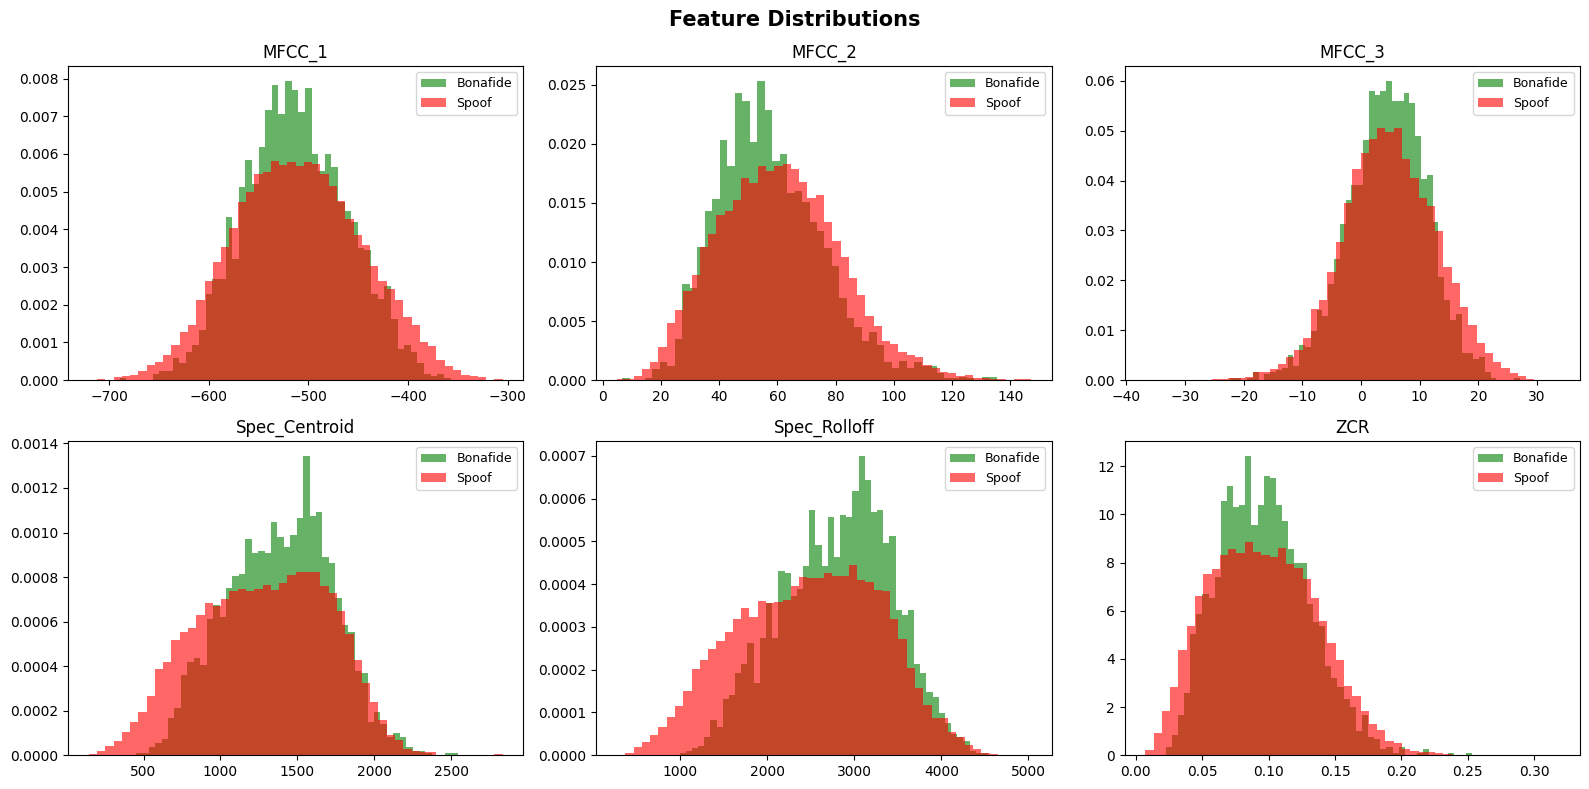

In [29]:
# ===== FEATURE DISTRIBUTIONS =====
fnames = ['MFCC_1','MFCC_2','MFCC_3','Spec_Centroid','Spec_Rolloff','ZCR']
fidx = [0,1,2,60,62,64]
fig,axes=plt.subplots(2,3,figsize=(16,8))
for ax,fi,fn in zip(axes.flat,fidx,fnames):
    ax.hist(train_data['hc'][train_data['labels']==0,fi],bins=50,alpha=.6,label='Bonafide',color='green',density=True)
    ax.hist(train_data['hc'][train_data['labels']==1,fi],bins=50,alpha=.6,label='Spoof',color='red',density=True)
    ax.set_title(fn); ax.legend(fontsize=9)
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## Imports

| Library | Purpose in this notebook |
|---------|------------------------|
| `torch`, `torch.nn`, `torch.optim`, `torch.nn.functional` | PyTorch — define CNN architecture, loss function, optimizer |
| `Dataset`, `DataLoader` | PyTorch utilities — batch and shuffle Mel spectrograms for CNN training |
| `LogisticRegression` | sklearn — our first baseline classifier |
| `SVC` | sklearn — Support Vector Machine classifier with RBF kernel |
| `StandardScaler` | sklearn — normalizes features to mean=0, std=1 before feeding to classifiers |
| `Pipeline` (as `SkPipeline`) | sklearn — chains scaler + classifier into one object (fit/predict in one call) |
| `accuracy_score`, `precision_score`, `recall_score`, `f1_score` | Evaluation metrics |
| `confusion_matrix` | Shows TP, TN, FP, FN counts |
| `roc_curve`, `auc` | ROC curve plotting and Area Under Curve calculation |
| `matplotlib`, `seaborn` | Plotting — confusion matrix heatmaps, training curves, bar charts |
| `LABEL_NAMES` | Display labels: index 0 = 'bonafide', index 1 = 'spoof' |

In [30]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
LABEL_NAMES = ['bonafide', 'spoof']
print('Imports OK')

Imports OK


---
## Load Pre-Extracted Features

This cell loads the features that were extracted and saved in Part 1. Each `.npz` file contains three arrays:

| Array | Shape | Description |
|-------|-------|-------------|
| `hc` | (N, 70) | Hand-crafted features — 70-dim vector per audio sample (for LR & SVM) |
| `mel` | (N, 128, 251) | Mel spectrograms — 128 freq bands × 251 time frames (for CNN) |
| `labels` | (N,) | Ground truth — 0 = bonafide (real), 1 = spoof (fake) |

In [ ]:
# ===== LOAD FEATURES =====
FEAT_DIR = '/Users/pobbamk/features'

def load_feat(name):
    d = np.load(os.path.join(FEAT_DIR, f'{name}_features.npz'))
    return {'hc': d['hc'], 'mel': d['mel'], 'labels': d['labels']}

train_data = load_feat('train')
dev_data   = load_feat('dev')
eval_data  = load_feat('eval')

for n,d in [('Train',train_data),('Dev',dev_data),('Eval',eval_data)]:
    print(f"{n}: HC {d['hc'].shape}, Mel {d['mel'].shape}, bon={np.sum(d['labels']==0)}, spf={np.sum(d['labels']==1)}")



---

## Evaluation Helper Functions

* Three functions used throughout the notebook to measure and display model performance.

##### `calc_metrics(y_true, y_pred, y_prob)` — Compute all metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Overall correct predictions |
| **Precision (Bonafide)** | TN / (TN + FN) | When model says "real," how often is it correct? |
| **Recall (Bonafide)** | TN / (TN + FP) | Of all real samples, how many did we correctly identify? |
| **Precision (Spoof)** | TP / (TP + FP) | When model says "fake," how often is it correct? |
| **Recall (Spoof)** | TP / (TP + FN) | Of all fake samples, how many did we catch? ← **most important for security** |
| **F1 Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean of precision and recall |
| **AUC** | Area under ROC curve | Overall quality of probability scores (1.0 = perfect, 0.5 = random) |


### Confusion Matrix layout:
```javascript
 Predicted Bonafide    Predicted Spoof
```

True Bonafide TN FP (false alarm) True Spoof FN (missed fake!) TP (caught fake)

```javascript

- **FP (False Positive):** Real speech wrongly flagged as fake → inconvenience
- **FN (False Negative):** Fake speech wrongly accepted as real → **security risk!**

### `show(metrics, name)` — Print metrics in a formatted table
### `plot_cm(metrics, name)` — Display confusion matrix as a color-coded heatmap
```


In [32]:
def calc_metrics(yt, yp, yprob=None):
    m = {'acc': accuracy_score(yt,yp),
         'prec_b': precision_score(yt,yp,pos_label=0,zero_division=0),
         'rec_b':  recall_score(yt,yp,pos_label=0,zero_division=0),
         'f1_b':   f1_score(yt,yp,pos_label=0,zero_division=0),
         'prec_s': precision_score(yt,yp,pos_label=1,zero_division=0),
         'rec_s':  recall_score(yt,yp,pos_label=1,zero_division=0),
         'f1_s':   f1_score(yt,yp,pos_label=1,zero_division=0),
         'f1_mac': f1_score(yt,yp,average='macro',zero_division=0)}
    cm = confusion_matrix(yt,yp,labels=[0,1])
    m['cm']=cm; m['FP']=cm[0,1]; m['FN']=cm[1,0]; m['TP']=cm[1,1]; m['TN']=cm[0,0]
    if yprob is not None:
        fpr,tpr,_=roc_curve(yt,yprob,pos_label=1)
        m['auc']=auc(fpr,tpr); m['fpr']=fpr; m['tpr']=tpr
    return m

def show(m, name):
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(f'  Accuracy: {m["acc"]:.4f}')
    print(f'  {"":<10}{"Prec":>8}{"Rec":>8}{"F1":>8}')
    print(f'  {"Bonafide":<10}{m["prec_b"]:>8.4f}{m["rec_b"]:>8.4f}{m["f1_b"]:>8.4f}')
    print(f'  {"Spoof":<10}{m["prec_s"]:>8.4f}{m["rec_s"]:>8.4f}{m["f1_s"]:>8.4f}')
    print(f'  FP:{m["FP"]} | FN:{m["FN"]} (missed deepfakes!)')
    if 'auc' in m: print(f'  AUC: {m["auc"]:.4f}')

def plot_cm(m, name):
    fig,ax=plt.subplots(figsize=(6,5))
    sns.heatmap(m['cm'],annot=True,fmt='d',cmap='Blues',
                xticklabels=LABEL_NAMES,yticklabels=LABEL_NAMES,ax=ax,annot_kws={'size':14})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {name}'); plt.tight_layout(); plt.show()

print('Helpers ready')

Helpers ready


---
## Logistic Regression

---
## Prepare Data for Classical ML

This cell separates features (X) and labels (y) for each split, ready for Logistic Regression and SVM.

- **`X_tr`, `X_dv`, `X_ev`** — Hand-crafted feature matrices (N × 70) for train, dev, eval
- **`y_tr`, `y_dv`, `y_ev`** — Label arrays (N,) where 0 = bonafide, 1 = spoof
- **`np.nan_to_num()`** — Replaces any NaN or Inf values with 0. Some audio files may produce undefined feature values (e.g., silent audio with zero energy), which would crash the classifiers.


In [33]:
X_tr=np.nan_to_num(train_data['hc']); y_tr=train_data['labels']
X_dv=np.nan_to_num(dev_data['hc']);   y_dv=dev_data['labels']
X_ev=np.nan_to_num(eval_data['hc']);  y_ev=eval_data['labels']
print(f'Train:{X_tr.shape} Dev:{X_dv.shape} Eval:{X_ev.shape}')

Train:(25380, 70) Dev:(24844, 70) Eval:(71237, 70)


---
## Model 1: Logistic Regression (Baseline)

A simple linear classifier that serves as our baseline. It computes a weighted sum of the 70 features and passes it through a sigmoid function to get a probability:

$$P(\text{spoof}) = \frac{1}{1 + e^{-(w_1 x_1 + w_2 x_2 + \cdots + w_{70} x_{70} + b)}}$$

If $P(\text{spoof}) > 0.5$ → predict spoof, otherwise predict bonafide.

### Pipeline steps:
1. **StandardScaler** — Normalizes each of the 70 features to mean=0, std=1 (using TRAIN statistics only)
2. **LogisticRegression** — Learns the 70 weights + bias

### Hyperparameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `C=1` | Regularization strength — controls overfitting (lower = more regularization) |
| `max_iter=1000` | Maximum optimization iterations |
| `random_state=42` | Fixed seed for reproducibility |
| `class_weight='balanced'` | Automatically adjusts weights inversely proportional to class frequencies — gives more importance to the minority class (bonafide) to handle the 9:1 imbalance |

### What `%%time` does:
Measures and prints the total execution time of the cell (training + evaluation).


  Logistic Regression (Eval)
  Accuracy: 0.7090
                Prec     Rec      F1
  Bonafide    0.2437  0.8646  0.3802
  Spoof       0.9779  0.6911  0.8098
  FP:996 | FN:19736 (missed deepfakes!)
  AUC: 0.8549


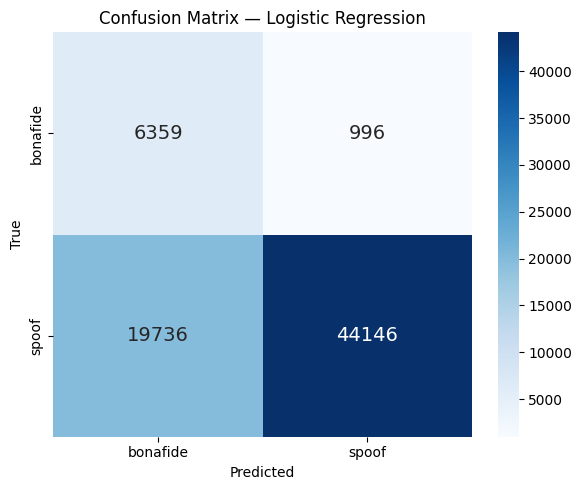

CPU times: user 238 ms, sys: 60.5 ms, total: 298 ms
Wall time: 370 ms


In [34]:
%%time
lr = SkPipeline([('sc',StandardScaler()),
    ('clf',LogisticRegression(C=1,max_iter=1000,random_state=42,class_weight='balanced'))])
lr.fit(X_tr, y_tr)
lr_m = calc_metrics(y_ev, lr.predict(X_ev), lr.predict_proba(X_ev)[:,1])
show(lr_m, 'Logistic Regression (Eval)'); plot_cm(lr_m, 'Logistic Regression')

---
## Model 2: SVM (Support Vector Machine)

A more powerful classifier that can find **nonlinear decision boundaries** using the kernel trick.

### How SVM works:
1. Maps each 70-dim feature vector into a higher-dimensional space using the RBF kernel
2. Finds the hyperplane with the **maximum margin** between bonafide and spoof classes
3. The "support vectors" are the samples closest to the boundary — they define the decision surface

### RBF Kernel:
$$K(x_i, x_j) = e^{-\gamma \| x_i - x_j \|^2}$$

This measures similarity between two audio samples. Nearby points in feature space get high similarity, distant points get low similarity.

### Pipeline steps:
1. **StandardScaler** — Same normalization as LR (fit on TRAIN only)
2. **SVC** — Support Vector Classifier with RBF kernel

### Hyperparameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `C=1` | Penalty for misclassification — higher C = stricter (less tolerant of errors) |
| `kernel='rbf'` | Radial Basis Function — allows curved, nonlinear decision boundaries |
| `gamma='scale'` | Kernel width — auto-calculated as 1/(n_features × variance) = 1/(70 × var) |
| `class_weight='balanced'` | Same as LR — upweights minority class (bonafide) |
| `probability=True` | Enables probability estimates via Platt scaling (needed for AUC/ROC) |

### Why SVM over LR?
LR draws a **flat** boundary (linear). SVM with RBF draws a **curved** boundary that can separate data that isn't linearly separable — which is the case for deepfake detection in 70-dim feature space.


  SVM (Eval)
  Accuracy: 0.8326
                Prec     Rec      F1
  Bonafide    0.3632  0.8252  0.5044
  Spoof       0.9764  0.8334  0.8993
  FP:1286 | FN:10640 (missed deepfakes!)
  AUC: 0.9057


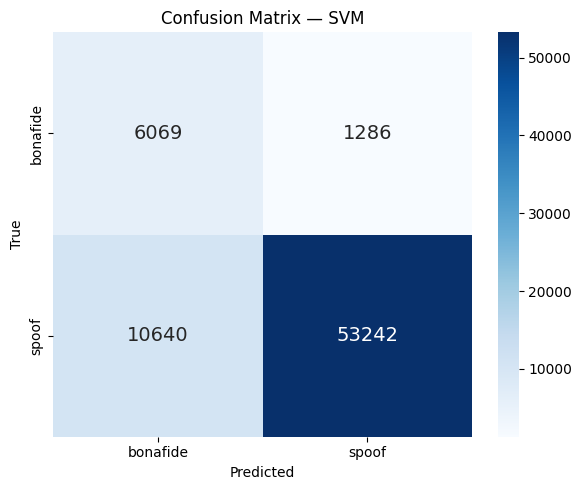

CPU times: user 1min 3s, sys: 635 ms, total: 1min 3s
Wall time: 1min 3s


In [36]:
%%time
svm = SkPipeline([('sc',StandardScaler()),
    ('clf',SVC(C=1,kernel='rbf',gamma='scale',random_state=42,class_weight='balanced',probability=True))])
svm.fit(X_tr, y_tr)
svm_m = calc_metrics(y_ev, svm.predict(X_ev), svm.predict_proba(X_ev)[:,1])
show(svm_m, 'SVM (Eval)'); plot_cm(svm_m, 'SVM')

---
## CNN Model Definition

---
## Model 3: CNN (Convolutional Neural Network)

A deep learning model that takes **Mel spectrogram images** (128 × 251) as input instead of hand-crafted features. It learns to detect visual patterns in spectrograms that distinguish real from fake speech.

### Architecture — 4 Convolutional Blocks + Classifier

Each convolutional block applies: **Conv2D → BatchNorm → ReLU → MaxPool**

| Layer | Input Shape | Output Shape | What it does |
|-------|------------|-------------|-------------|
| **Conv Block 1** | (1, 128, 251) | (32, 64, 125) | 32 filters detect basic patterns (edges, energy blobs) |
| **Conv Block 2** | (32, 64, 125) | (64, 32, 62) | 64 filters detect combinations of basic patterns |
| **Conv Block 3** | (64, 32, 62) | (128, 16, 31) | 128 filters detect complex spectral structures |
| **Conv Block 4** | (128, 16, 31) | (256, 8, 15) | 256 filters detect high-level audio characteristics |
| **Global Avg Pool** | (256, 8, 15) | (256, 1, 1) | Averages each filter's output into a single number |
| **Flatten** | (256, 1, 1) | (256,) | Reshape to a 1D vector |
| **Dropout (50%)** | (256,) | (256,) | Randomly zeros half the values (prevents overfitting) |
| **FC Layer 1** | (256,) | (128,) | Fully connected layer + ReLU activation |
| **Dropout (30%)** | (128,) | (128,) | More dropout for regularization |
| **FC Layer 2** | (128,) | (2,) | Output: 2 scores (bonafide vs spoof) |

### Key components explained:
- **Conv2d(in, out, 3, 1, 1)** — 3×3 filter, stride 1, padding 1 (preserves spatial size)
- **BatchNorm2d** — Normalizes activations to stabilize training
- **ReLU** — Activation function: $f(x) = \max(0, x)$
- **MaxPool2d(2)** — Halves height and width (keeps strongest activations)
- **AdaptiveAvgPool2d(1,1)** — Global average pooling regardless of input size
- **Dropout** — Randomly disables neurons during training to prevent overfitting

In [37]:
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1,32,3,1,1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(nn.Conv2d(32,64,3,1,1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(nn.Conv2d(64,128,3,1,1),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2))
        self.conv4 = nn.Sequential(nn.Conv2d(128,256,3,1,1),nn.BatchNorm2d(256),nn.ReLU(),nn.MaxPool2d(2))
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(nn.Dropout(.5),nn.Linear(256,128),nn.ReLU(),nn.Dropout(.3),nn.Linear(128,2))
    def forward(self, x):
        x=self.conv1(x); x=self.conv2(x); x=self.conv3(x); x=self.conv4(x)
        x=self.gap(x); x=x.view(x.size(0),-1); return self.fc(x)

model = DeepfakeCNN()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN Parameters: {n_params:,}')
print(model)

CNN Parameters: 421,954
DeepfakeCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddi


## CNN Dataset & DataLoaders

### `MelDS` — Custom PyTorch Dataset

Wraps Mel spectrograms and labels into a format PyTorch can iterate over.

**Normalization step:**
- Raw Mel spectrograms range from −80 dB (silence) to 0 dB (loudest)
- We shift and scale to [0, 1]: `(mel + 80) / 80`
- Then clip to ensure values stay in [0, 1]
- This makes training more stable (neural networks prefer inputs near 0-1)

**`__getitem__` returns:**
- Spectrogram tensor of shape (1, 128, 251) — the `unsqueeze(0)` adds a channel dimension (like a grayscale image)
- Label tensor: 0 or 1

### DataLoaders — Batch and shuffle the data

| DataLoader | Data | Shuffle? | Purpose |
|-----------|------|----------|---------|
| `tr_dl` | Training spectrograms | ✅ Yes | Shuffling prevents the model from learning the order of samples |
| `dv_dl` | Dev spectrograms | ❌ No | Just for evaluation — order doesn't matter |
| `ev_dl` | Eval spectrograms | ❌ No | Final testing — order doesn't matter |

**Batch size = 32** means the CNN processes 32 spectrograms at a time. Each batch is a tensor of shape (32, 1, 128, 251).

In [40]:
class MelDS(Dataset):
    def __init__(self, mels, labels):
        self.mels = (mels.astype(np.float32)+80.)/80.
        self.mels = np.clip(self.mels, 0, 1)
        self.labels = labels.astype(np.int64)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return torch.from_numpy(self.mels[i]).unsqueeze(0), torch.tensor(self.labels[i])

BS = 32
tr_dl = DataLoader(MelDS(train_data['mel'],train_data['labels']),batch_size=BS,shuffle=True)
dv_dl = DataLoader(MelDS(dev_data['mel'],dev_data['labels']),batch_size=BS)
ev_dl = DataLoader(MelDS(eval_data['mel'],eval_data['labels']),batch_size=BS)
print(f'Batches — Train:{len(tr_dl)} Dev:{len(dv_dl)} Eval:{len(ev_dl)}')

Batches — Train:794 Dev:777 Eval:2227


---
## CNN Training Setup

### Device Selection
Automatically picks the best available hardware:
- **MPS** — Apple Silicon GPU (M1/M2/M3 Macs)
- **CUDA** — NVIDIA GPU
- **CPU** — Fallback if no GPU available

### Class Weights (Handling Imbalance)
The training set has ~9× more spoof than bonafide samples. Without correction, the CNN would learn to predict "spoof" for everything.

Formula: $w_c = \frac{N_{total}}{N_{classes} \times N_c}$

Example with 25,380 samples (2,580 bonafide + 22,800 spoof):
- $w_{bonafide} = \frac{25380}{2 \times 2580} = 4.92$ (upweighted — errors on bonafide cost more)
- $w_{spoof} = \frac{25380}{2 \times 22800} = 0.56$ (downweighted — errors on spoof cost less)

### Loss, Optimizer, Scheduler

| Component | Setting | Purpose |
|-----------|---------|---------|
| **CrossEntropyLoss** | weighted | Combines softmax + log loss; class weights penalize bonafide errors more |
| **Adam optimizer** | lr=0.0005, weight_decay=1e-4 | Adaptive learning rate optimizer with L2 regularization |
| **ReduceLROnPlateau** | factor=0.5, patience=3 | Halves the learning rate if validation loss doesn't improve for 3 epochs |

In [66]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
model = DeepfakeCNN().to(device)

# Class weights
n_s = len(train_data['labels']); n_c = 2
counts = np.bincount(train_data['labels'])
weights = torch.FloatTensor(n_s / (n_c * counts)).to(device)
print(f'Device: {device}, Weights: bon={weights[0]:.3f} spf={weights[1]:.3f}')

criterion = nn.CrossEntropyLoss(weight=weights)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)  # lr changed from 0.001 to 0.0005

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

Device: mps, Weights: bon=4.919 spf=0.557


---
## CNN Training Loop

Trains the CNN for up to 50 epochs with early stopping.

### What happens each epoch:

**1. Training phase** (`model.train()`):
- Iterate over training batches (32 spectrograms each)
- For each batch: forward pass → compute loss → backpropagate → update weights
- Track training loss and accuracy

**2. Validation phase** (`model.eval()`, `torch.no_grad()`):
- Iterate over dev batches — NO weight updates
- Compute validation loss and accuracy
- This tells us if the model is improving or overfitting

**3. Learning rate scheduling:**
- `scheduler.step(vl)` — if val loss hasn't improved for 3 epochs, halve the learning rate

**4. Early stopping & checkpointing:**
- If val loss improves → save model to `best_cnn.pth` (marked with `*saved*`)
- If val loss doesn't improve for 10 consecutive epochs → stop training early
- This prevents overfitting — the model stops before it memorizes the training data

### Output columns explained:

| Column | Meaning |
|--------|---------|
| `Ep` | Current epoch / total epochs |
| `TrL` | Training loss (lower = better) |
| `TrA` | Training accuracy |
| `VL` | Validation loss (lower = better) — this is what we monitor |
| `VA` | Validation accuracy |
| `*saved*` | Model checkpoint saved (val loss improved) |

### Key difference from LR/SVM:
LR and SVM train in one step (`fit()`). The CNN trains iteratively over many epochs, gradually improving. Early stopping acts as a form of regularization — similar to `C` in LR/SVM.

In [67]:
EPOCHS = 50; PATIENCE = 10
# EPOCHS = 20; PATIENCE = 5
best_vl = float('inf'); wait = 0
tl_hist, vl_hist = [], []

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    # Train
    model.train(); rl=0; cor=0; tot=0
    for x,y in tr_dl:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad(); out=model(x); loss=criterion(out,y)
        loss.backward(); optimizer.step()
        rl+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=y.size(0)
    tl=rl/tot; ta=cor/tot
    # Val
    model.eval(); rl=0; cor=0; tot=0
    with torch.no_grad():
        for x,y in dv_dl:
            x,y=x.to(device),y.to(device); out=model(x); loss=criterion(out,y)
            rl+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=y.size(0)
    vl=rl/tot; va=cor/tot
    scheduler.step(vl)
    tl_hist.append(tl); vl_hist.append(vl)
    dt = time.time()-t0
    print(f'Ep {ep:2d}/{EPOCHS} | TrL:{tl:.4f} TrA:{ta:.4f} | VL:{vl:.4f} VA:{va:.4f} | {dt:.1f}s', end='')
    if vl < best_vl:
        best_vl=vl; wait=0; torch.save(model.state_dict(),'best_cnn.pth'); print(' *saved*')
    else:
        wait+=1; print()
        if wait>=PATIENCE: print(f'Early stop at epoch {ep}'); break

print('Training complete!')

Ep  1/50 | TrL:0.2712 TrA:0.8784 | VL:0.0745 VA:0.9735 | 75.2s *saved*
Ep  2/50 | TrL:0.0738 TrA:0.9744 | VL:0.1199 VA:0.9547 | 56.3s
Ep  3/50 | TrL:0.0438 TrA:0.9867 | VL:0.0061 VA:0.9981 | 56.5s *saved*
Ep  4/50 | TrL:0.0258 TrA:0.9915 | VL:0.0052 VA:0.9982 | 56.8s *saved*
Ep  5/50 | TrL:0.0181 TrA:0.9942 | VL:0.0015 VA:0.9995 | 56.2s *saved*
Ep  6/50 | TrL:0.0266 TrA:0.9921 | VL:0.0061 VA:0.9982 | 56.3s
Ep  7/50 | TrL:0.0159 TrA:0.9954 | VL:0.0139 VA:0.9956 | 56.2s
Ep  8/50 | TrL:0.0177 TrA:0.9943 | VL:0.1855 VA:0.9496 | 56.6s
Ep  9/50 | TrL:0.0218 TrA:0.9936 | VL:0.0122 VA:0.9954 | 56.3s
Ep 10/50 | TrL:0.0043 TrA:0.9984 | VL:0.0008 VA:0.9998 | 55.7s *saved*
Ep 11/50 | TrL:0.0075 TrA:0.9975 | VL:0.0011 VA:0.9997 | 55.2s
Ep 12/50 | TrL:0.0029 TrA:0.9992 | VL:0.0135 VA:0.9950 | 55.3s
Ep 13/50 | TrL:0.0092 TrA:0.9975 | VL:0.0016 VA:0.9997 | 55.5s
Ep 14/50 | TrL:0.0033 TrA:0.9989 | VL:0.0006 VA:0.9999 | 56.2s *saved*
Ep 15/50 | TrL:0.0055 TrA:0.9982 | VL:0.0007 VA:0.9998 | 57.5s
Ep 16/5

---
## CNN Training Curves

Plots training loss (blue) and validation loss (red) across epochs.

### How to interpret:
- **Both lines decreasing** → model is learning ✅
- **Train loss decreasing, val loss increasing** → overfitting (model memorizes training data) ⚠️
- **Both lines flat near zero** → model has converged ✅
- **Sudden spikes in val loss** → unstable training (batch noise or learning rate too high)
- **Gap between train and val** → some overfitting, but acceptable if val loss is still low

### Ideal curve shape:
Both lines should drop quickly in early epochs, then flatten near zero. The best model checkpoint (`*saved*`) corresponds to the lowest point on the red (val loss) line.

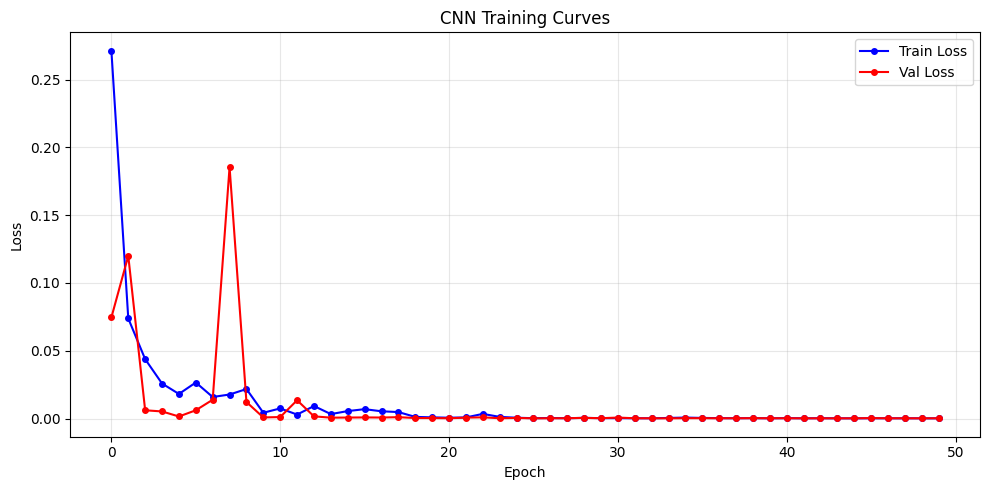

In [68]:
# Training curves
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(tl_hist,'b-o',label='Train Loss',ms=4)
ax.plot(vl_hist,'r-o',label='Val Loss',ms=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('CNN Training Curves'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## CNN Evaluation on Eval Set

This cell loads the **best model checkpoint** (not the last epoch) and evaluates it on the unseen eval set.

### Steps:
1. **Load best weights** — `torch.load('best_cnn.pth')` loads the checkpoint saved at the epoch with the lowest validation loss
2. **Set eval mode** — `model.eval()` disables dropout and uses running statistics for BatchNorm (different behavior from training)
3. **No gradients** — `torch.no_grad()` disables gradient computation (faster, less memory)
4. **Process eval batches** — for each batch of 32 spectrograms:
   - Forward pass through CNN → raw output scores (logits)
   - `softmax` converts logits to probabilities: $P(\text{spoof}) = \frac{e^{z_1}}{e^{z_0} + e^{z_1}}$
   - `argmax` picks the class with higher probability → prediction (0 or 1)
5. **Compute metrics** — compare predictions to true labels

### Why we load `best_cnn.pth` instead of using the current model:
During training, the model may have gotten worse after the best epoch (overfitting). The saved checkpoint guarantees we evaluate the best version of the model, not the last.

### This is the TRUE test:
The eval set contains **unseen speakers** (67 new people) and **unseen attack types** (A07–A19). The model has never seen any of this data during training or validation.


  CNN (Eval)
  Accuracy: 0.5944
                Prec     Rec      F1
  Bonafide    0.2028  0.9992  0.3372
  Spoof       0.9998  0.5478  0.7078
  FP:6 | FN:28889 (missed deepfakes!)
  AUC: 0.8813


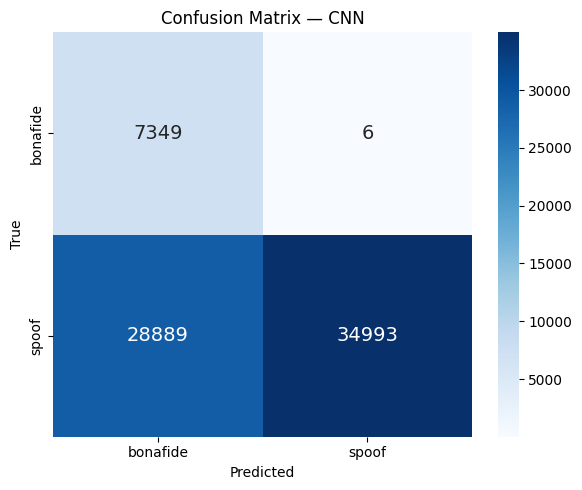

In [69]:
model.load_state_dict(torch.load('best_cnn.pth', map_location=device, weights_only=True))
model.eval()
preds, trues, probs = [], [], []
with torch.no_grad():
    for x,y in ev_dl:
        x=x.to(device); out=model(x); p=torch.softmax(out,1)
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(y.numpy())
        probs.extend(p[:,1].cpu().numpy())
cnn_m = calc_metrics(np.array(trues), np.array(preds), np.array(probs))
show(cnn_m, 'CNN (Eval)'); plot_cm(cnn_m, 'CNN')

---
## Model Comparison

Side-by-side comparison of all three models evaluated on the **same eval set** (71,237 samples, unseen A07–A19 attacks).



| Column | Meaning | Good value |
|--------|---------|-----------|
| **Acc** | Overall accuracy | Higher = better |
| **Prec(S)** | Spoof precision — when model says "spoof," how often is it right? | Higher = fewer false alarms |
| **Rec(S)** | Spoof recall — of all actual spoofs, how many did we catch? | **Higher = fewer missed deepfakes (most important!)** |
| **F1(S)** | Harmonic mean of Prec(S) and Rec(S) | Higher = better balance |
| **FN** | False negatives — deepfakes that passed as real | **Lower = safer** |
| **FP** | False positives — real speech flagged as fake | Lower = less annoying |
| **AUC** | Area under ROC curve | Closer to 1.0 = better |

### Cybersecurity priority:
For a security system, **Rec(S) and FN are the most critical metrics**. A missed deepfake (FN) means an attacker's fake voice passes through undetected. False alarms (FP) are annoying but not dangerous.

In [71]:
all_m = {'Logistic Regression': lr_m, 'SVM': svm_m, 'CNN': cnn_m}

print(f'\n{"="*75}')
print(f'  MODEL COMPARISON TABLE')
print(f'{"="*75}')
print(f'{"Model":<22}{"Acc":>8}{"Prec(S)":>9}{"Rec(S)":>9}{"F1(S)":>9}{"FN":>7}{"FP":>7}{"AUC":>8}')
print('-'*75)
for name, m in all_m.items():
    a = m.get('auc', 0)
    print(f'{name:<22}{m["acc"]:>8.4f}{m["prec_s"]:>9.4f}{m["rec_s"]:>9.4f}{m["f1_s"]:>9.4f}{m["FN"]:>7}{m["FP"]:>7}{a:>8.4f}')
print('-'*75)
best = max(all_m.items(), key=lambda x: x[1]['rec_s'])
print(f'\nBest spoof detection: {best[0]} (recall={best[1]["rec_s"]:.4f})')


  MODEL COMPARISON TABLE
Model                      Acc  Prec(S)   Rec(S)    F1(S)     FN     FP     AUC
---------------------------------------------------------------------------
Logistic Regression     0.7090   0.9779   0.6911   0.8098  19736    996  0.8549
SVM                     0.8326   0.9764   0.8334   0.8993  10640   1286  0.9057
CNN                     0.5944   0.9998   0.5478   0.7078  28889      6  0.8813
---------------------------------------------------------------------------

Best spoof detection: SVM (recall=0.8334)


Add this markdown cell above the ROC curves code cell:

```markdown
---
## ROC Curves — All Models

The ROC (Receiver Operating Characteristic) curve shows the trade-off between catching deepfakes and creating false alarms at every possible decision threshold.

### Axes:
- **X-axis (FPR):** False Positive Rate — fraction of real speech wrongly flagged as fake
- **Y-axis (TPR):** True Positive Rate — fraction of deepfakes correctly detected

### How to read it:
- **Upper-left corner** = perfect classifier (catches all fakes, no false alarms)
- **Diagonal dashed line** = random guessing (useless model)
- **Curve closer to upper-left** = better model
- **AUC (Area Under Curve):** Single number summarizing the curve. AUC = 1.0 is perfect, AUC = 0.5 is random.

### Why ROC matters:
In practice, you choose a threshold based on your security needs:
- **High-security setting:** Move right on the curve — catch more deepfakes but accept more false alarms
- **Low-annoyance setting:** Stay left — fewer false alarms but risk missing some deepfakes
```


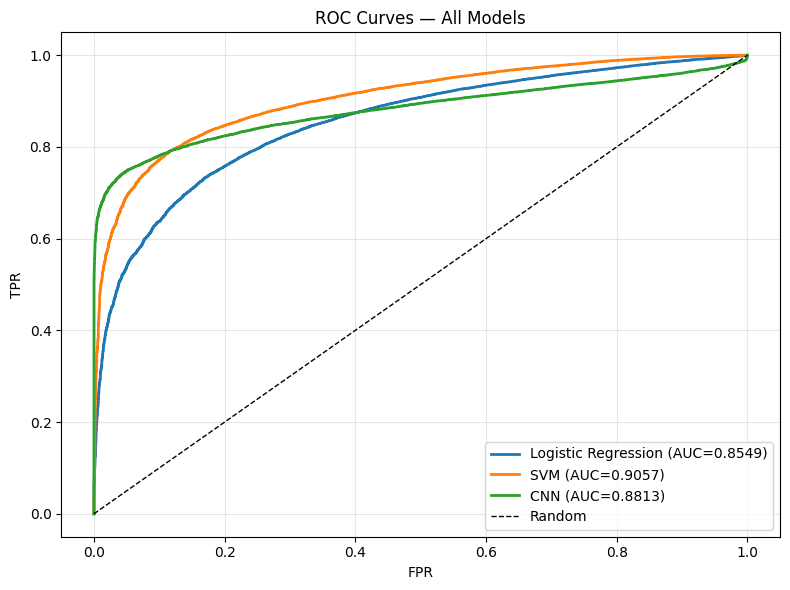

In [72]:
# ROC Curves
fig,ax=plt.subplots(figsize=(8,6))
for name,m in all_m.items():
    if 'fpr' in m: ax.plot(m['fpr'],m['tpr'],lw=2,label=f'{name} (AUC={m["auc"]:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## Bar Chart — Model Comparison

Visual side-by-side comparison of four key metrics across all models.

### Metrics shown:
- **Accuracy** — overall correct predictions (can be misleading with imbalanced data)
- **Precision(S)** — of samples predicted as spoof, what fraction are truly spoof?
- **Recall(S)** — of all actual spoof samples, what fraction did we detect?
- **F1(S)** — balanced combination of precision and recall for the spoof class

### What to look for:
- The tallest bar in **Recall(S)** indicates the best model at catching deepfakes
- A model with high Precision but low Recall is "cautious" — rarely cries wolf, but misses many fakes
- A model with high Recall but low Precision is "aggressive" — catches most fakes but also flags many real samples
- **F1** balances both — a good single metric for comparison

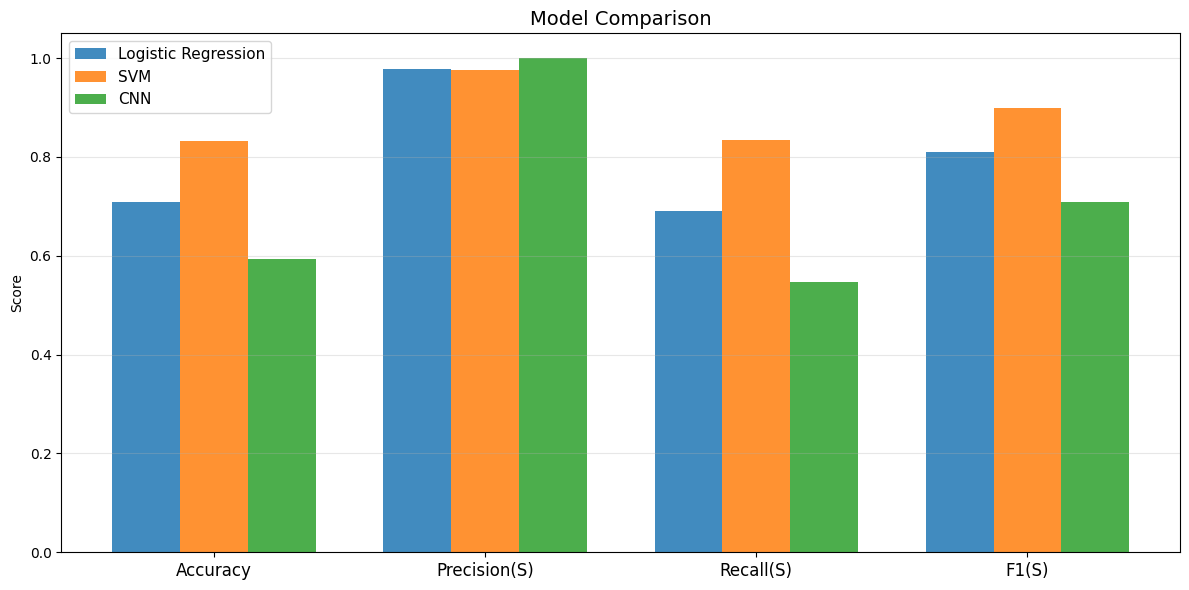

In [73]:
# Bar chart comparison
metrics_to_plot = ['acc','prec_s','rec_s','f1_s']
labels = ['Accuracy','Precision(S)','Recall(S)','F1(S)']
x = np.arange(len(labels)); w = 0.25
fig,ax=plt.subplots(figsize=(12,6))
for i,(name,m) in enumerate(all_m.items()):
    vals = [m[k] for k in metrics_to_plot]
    ax.bar(x+i*w, vals, w, label=name, alpha=.85)
ax.set_xticks(x+w); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score'); ax.set_title('Model Comparison', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=.3, axis='y'); ax.set_ylim(0,1.05)
plt.tight_layout(); plt.show()

---
## Cybersecurity Analysis
---
## Cybersecurity Error Analysis

This is the most important section from a **security perspective**. Not all errors are equal:

### Two types of errors:

| Error Type | What happens | Real-world impact | Severity |
|-----------|-------------|-------------------|----------|
| **False Negative (FN)** | Deepfake audio classified as real | Attacker's fake voice call passes through — could authorize a fraudulent wire transfer, bypass voice authentication, or impersonate an executive | 🚨 **Critical — security breach** |
| **False Positive (FP)** | Real audio classified as fake | A legitimate user gets flagged — they need to re-authenticate or use an alternative method | ⚠️ **Annoying but safe** |

### Why we prioritize Recall over Accuracy:
- A model with 95% accuracy but 50% spoof recall **misses half of all deepfakes** — useless for security
- A model with 80% accuracy but 90% spoof recall **catches 90% of deepfakes** — much safer, even though overall accuracy is lower
- In cybersecurity, **it's better to be safe than convenient**


In [74]:
print('='*60)
print('  CYBERSECURITY ERROR ANALYSIS')
print('='*60)
print()
print('False Negatives (FN) = spoof classified as bonafide')
print('  -> GREATEST SECURITY RISK: deepfake passes undetected!')
print()
print('False Positives (FP) = bonafide classified as spoof')
print('  -> Inconvenience: legitimate speech flagged as fake')
print()
print(f'{"Model":<22}{"FN (missed fakes)":>20}{"FP (false alarms)":>20}')
print('-'*62)
for name, m in all_m.items():
    print(f'{name:<22}{m["FN"]:>20}{m["FP"]:>20}')
print()
best_fn = min(all_m.items(), key=lambda x: x[1]['FN'])
best_rec = max(all_m.items(), key=lambda x: x[1]['rec_s'])
print(f'Fewest missed deepfakes: {best_fn[0]} (FN={best_fn[1]["FN"]})')
print(f'Best spoof recall:       {best_rec[0]} (recall={best_rec[1]["rec_s"]:.4f})')
print()
print('RECOMMENDATION: For security-critical deployment, prioritize')
print('models with HIGH spoof recall over raw accuracy.')

  CYBERSECURITY ERROR ANALYSIS

False Negatives (FN) = spoof classified as bonafide
  -> GREATEST SECURITY RISK: deepfake passes undetected!

False Positives (FP) = bonafide classified as spoof
  -> Inconvenience: legitimate speech flagged as fake

Model                    FN (missed fakes)   FP (false alarms)
--------------------------------------------------------------
Logistic Regression                  19736                 996
SVM                                  10640                1286
CNN                                  28889                   6

Fewest missed deepfakes: SVM (FN=10640)
Best spoof recall:       SVM (recall=0.8334)

RECOMMENDATION: For security-critical deployment, prioritize
models with HIGH spoof recall over raw accuracy.


---
## Error Comparison — Cybersecurity Perspective

Two bar charts showing the actual error counts for each model:

### Left chart: False Negatives (Red bars)
- Number of **deepfake audio samples that were missed** — classified as real when they were actually fake
- This is the **critical security metric** — each missed deepfake is a potential attack that succeeds
- Lower is better

### Right chart: False Positives (Orange bars)
- Number of **real audio samples wrongly flagged** as fake
- These cause inconvenience (legitimate users blocked) but no security breach
- Lower is better, but less critical than FN

### The security trade-off:
Reducing FN (catching more fakes) often increases FP (more false alarms). The ideal model minimizes both, but if forced to choose, a security system should **prioritize low FN over low FP** — it's better to inconvenience some legitimate users than to let deepfake attacks through.

In [ ]:
# Error comparison bar chart
fig,axes=plt.subplots(1,2,figsize=(14,5))
names = list(all_m.keys())
fns = [all_m[n]['FN'] for n in names]
fps = [all_m[n]['FP'] for n in names]

axes[0].bar(names, fns, color='#e74c3c', alpha=.8, edgecolor='k')
axes[0].set_title('False Negatives (Missed Deepfakes)', fontsize=13)
axes[0].set_ylabel('Count')
for b,v in zip(axes[0].patches, fns):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold')

axes[1].bar(names, fps, color='#f39c12', alpha=.8, edgecolor='k')
axes[1].set_title('False Positives (False Alarms)', fontsize=13)
axes[1].set_ylabel('Count')
for b,v in zip(axes[1].patches, fps):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold')

plt.suptitle('Error Analysis — Cybersecurity', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print('\n✅ Analysis complete!')

## Per-Attack AUC & EER Analysis with Math Explanations

---
## Mathematical Background

### AUC (Area Under the ROC Curve)

The ROC curve plots **True Positive Rate** vs **False Positive Rate** at every possible threshold:

$$TPR = \frac{TP}{TP + FN} \quad \text{(how many spoofs we catch)}$$

$$FPR = \frac{FP}{FP + TN} \quad \text{(how many real voices we wrongly flag)}$$

**AUC = 1.0** means perfect separation. **AUC = 0.5** means random guessing.

### EER (Equal Error Rate)

EER is the point on the ROC curve where:

$$\text{False Accept Rate (FAR)} = \text{False Reject Rate (FRR)}$$

Where:
- **FAR** = fraction of spoof samples incorrectly accepted as bonafide = $\frac{FN}{FN + TP}$
- **FRR** = fraction of bonafide samples incorrectly rejected = $\frac{FP}{FP + TN}$

**Lower EER = better.** An EER of 0% means perfect detection. EER of 50% means useless.

### ASVspoof 2019 Attack Systems

| System | Type | Method | In Training? |
|--------|------|--------|--------------|
| A01-A06 | Known | Various TTS/VC | Yes |
| A07-A19 | **Unknown** | Various TTS/VC | **No** |

The real challenge is detecting **A07-A19** — attacks the model has never seen during training.

In [76]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import roc_curve, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
print('Imports OK')

Imports OK


## Extract Prediction Probabilities for Per-Attack Analysis

This cell collects the **spoof probability scores** from all three models on the eval set. These probabilities are needed for computing AUC and EER per attack system.

### What each line does:
- `lr.predict_proba(X_ev)[:,1]` — LR's estimated P(spoof) for each eval sample, shape (71237,)
- `svm.predict_proba(X_ev)[:,1]` — SVM's estimated P(spoof), shape (71237,)
- CNN loop with `torch.softmax(out, 1)[:,1]` — CNN's P(spoof) from softmax output

### Why we need probabilities (not just predictions):
- `predict()` gives binary labels (0 or 1) — only works at a single threshold
- `predict_proba()` gives continuous scores (0.0 to 1.0) — needed to compute ROC curves, AUC, and EER at all possible thresholds

### `[:,1]` means:
Both `predict_proba()` and `softmax()` return two columns: [P(bonafide), P(spoof)]. We take column index 1 = P(spoof).



In [77]:
# Create probability arrays needed for per-attack analysis
lr_probs = lr.predict_proba(X_ev)[:,1]
svm_probs = svm.predict_proba(X_ev)[:,1]

# CNN probs (if not already computed)
model.eval()
cnn_probs_list = []
with torch.no_grad():
    for x, y in ev_dl:
        x = x.to(device)
        p = torch.softmax(model(x), 1)
        cnn_probs_list.extend(p[:,1].cpu().numpy())
cnn_probs = np.array(cnn_probs_list)

print(f'LR probs: {lr_probs.shape}, SVM probs: {svm_probs.shape}, CNN probs: {cnn_probs.shape}')


LR probs: (71237,), SVM probs: (71237,), CNN probs: (71237,)


---
## EER (Equal Error Rate) Computation

EER is the standard metric in speaker verification and anti-spoofing research.

### What is EER?

At any decision threshold, there are two error rates:
- **FAR (False Accept Rate)** = fraction of spoof samples incorrectly accepted as bonafide = FPR
- **FRR (False Reject Rate)** = fraction of bonafide samples incorrectly rejected = 1 − TPR

**EER is the threshold where FAR = FRR.** It's a single number that summarizes detection performance.

$$\text{EER} = \text{FPR}^* \text{ where } \text{FPR}^* = 1 - \text{TPR}^*$$

### How the code computes it:
1. `roc_curve()` computes (FPR, TPR) at many thresholds
2. `interp1d(fpr, tpr)` creates a smooth interpolation of the ROC curve
3. `brentq()` finds the point where `FPR = 1 − TPR` (i.e., FAR = FRR) using root-finding

### Interpretation:
- **EER = 0%** → perfect detector (never confuses real and fake)
- **EER = 50%** → random guessing (completely useless)
- **EER = 10%** → at the optimal threshold, 10% of spoofs are missed AND 10% of bonafide are wrongly flagged
- Lower EER = better model

### EER vs AUC:
- **AUC** summarizes performance across ALL thresholds
- **EER** gives performance at ONE specific (optimal) threshold
- Both are useful; EER is more common in anti-spoofing literature

In [146]:
def compute_eer(y_true, y_scores):
    """Compute Equal Error Rate.
    
    EER is the point where FAR = FRR on the ROC curve.
    FAR (False Accept Rate) = FPR
    FRR (False Reject Rate) = 1 - TPR
    EER is where FPR = 1 - TPR
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    # EER is where FPR = 1 - TPR (i.e., FPR = FNR)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def compute_auc_score(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    return auc(fpr, tpr)

# Test on full eval set
for name, probs in [('LR', lr_probs), ('SVM', svm_probs), ('CNN', cnn_probs)]:
    eer = compute_eer(y_ev, probs)
    auc_val = compute_auc_score(y_ev, probs)
    print(f'{name}: AUC={auc_val:.4f}, EER={eer:.4f} ({eer*100:.2f}%)')

LR: AUC=0.8549, EER=0.2228 (22.28%)
SVM: AUC=0.9057, EER=0.1698 (16.98%)
CNN: AUC=0.8813, EER=0.1821 (18.21%)


---
## Re-Parse Eval Protocol for Attack System IDs

We re-parse the eval protocol file to get the **attack system ID** (A07–A19) for each sample. This is needed for per-attack analysis.

### Why re-parse?
The `df_ev` from Part 1 used `p[2]` for the system column (which is always `-`). Here we use `p[3]` to get the actual attack system ID.

### Protocol format reminder:
    LA_0039 LA_E_2834763 - A11 spoof p[0] p[1] p[2] p[3] p[4]

```javascript
- `p[2]` = `-` (separator, always a dash)
- `p[3]` = `A11` (the attack system that generated this fake audio)
- For bonafide samples, `p[3]` = `-` (no attack system)

### Expected output:
Systems found: `['-', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']`

The `-` entries are bonafide (real) samples. A07–A19 are the 13 different deepfake generation systems used in the eval set.
```


In [79]:
EVAL_PROTO = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.eval.trl.txt')

rows = []
with open(EVAL_PROTO) as f:
    for line in f:
        p = line.strip().split()
        if len(p) >= 5:
            rows.append({'speaker':p[0], 'filename':p[1], 'system':p[3],
                         'key':p[4], 'label':0 if p[4]=='bonafide' else 1})
df_eval = pd.DataFrame(rows)
print(f'Eval protocol: {len(df_eval)} entries, Systems: {sorted(df_eval.system.unique())}')

Eval protocol: 71237 entries, Systems: ['-', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']


---
## Match Protocol to Feature Data

The protocol file has 71,237 entries, but our features may have fewer samples (if `MAX_N` was set during extraction). This cell aligns the protocol's system IDs with our feature data.

### Two cases:
1. **Full dataset** (`n_eval == n_proto`): Direct match — each feature row corresponds to the same protocol row
2. **Subset** (`n_eval < n_proto`): We replicate the same stratified random sampling used in Part 1 (same `random_state=42`) to reconstruct which protocol entries were selected

### Output:
- `systems` array — attack system ID for each eval sample (e.g., '-', 'A07', 'A11', etc.)
- `attack_systems` — list of unique attack IDs to analyze (A07–A19, excluding '-' which is bonafide)
- `bon_idx` — indices of bonafide samples in the feature array (used to build per-attack subsets)

### How per-attack subsets are built:
For each attack system (e.g., A11), we combine:
- All bonafide samples (as the "real" class)
- Only spoof samples from that specific system (as the "fake" class)

This lets us measure how well each model detects each individual attack type separately.

Per-Attack Analysis
For each spoofing system (A01–A19), we compute AUC and EER using only:

All bonafide samples (as negatives)
Spoof samples from that specific system (as positives)
This tells us which attack types are easiest/hardest to detect.

In [80]:
# Match eval protocol with our eval data
# We need to replicate the same sampling that Part 1 used
n_eval = len(y_ev)
n_proto = len(df_eval)
print(f'Eval features: {n_eval} samples, Protocol: {n_proto} entries')

if n_eval == n_proto:
    # Full dataset was used
    df_eval_used = df_eval.copy()
    print('Full dataset match!')
else:
    # Subset was used - replicate the same stratified sampling from Part 1
    max_n = n_eval
    db = df_eval[df_eval.label == 0]
    ds = df_eval[df_eval.label == 1]
    nb = min(len(db), max_n // 2)
    ns = min(len(ds), max_n - nb)
    df_eval_used = pd.concat([
        db.sample(nb, random_state=42),
        ds.sample(ns, random_state=42)
    ]).reset_index(drop=True)
    print(f'Replicated sampling: {len(df_eval_used)} samples ({nb} bon, {ns} spf)')

systems = df_eval_used['system'].values[:n_eval]
print(f'\nSystems in our data: {sorted(set(systems))}')
print(f'System counts:')
sys_unique, sys_counts = np.unique(systems, return_counts=True)
for s, c in zip(sys_unique, sys_counts):
    print(f'  {s}: {c}')

# Get unique attack systems (exclude '-' which is bonafide)
attack_systems = sorted([s for s in sys_unique if s != '-'])
print(f'\nAttack systems to analyze: {attack_systems}')

# Bonafide indices
bon_idx = np.where(y_ev == 0)[0]
print(f'Bonafide samples: {len(bon_idx)}')

Eval features: 71237 samples, Protocol: 71237 entries
Full dataset match!

Systems in our data: ['-', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']
System counts:
  -: 7355
  A07: 4914
  A08: 4914
  A09: 4914
  A10: 4914
  A11: 4914
  A12: 4914
  A13: 4914
  A14: 4914
  A15: 4914
  A16: 4914
  A17: 4914
  A18: 4914
  A19: 4914

Attack systems to analyze: ['A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']
Bonafide samples: 7355


---
## Compute Per-Attack AUC & EER

For each attack system (A07–A19), we evaluate each model separately to find which deepfake methods are hardest to detect.

### How it works for each attack (e.g., A11):
1. **Select samples:** all bonafide (7,355) + only A11 spoof samples (4,914) = 12,269 total
2. **Get their probabilities** from each model (LR, SVM, CNN)
3. **Compute AUC and EER** on this subset — tells us how well each model detects A11 specifically

### Why per-attack matters:
The overall metrics average performance across ALL 13 attack types. But some attacks (like A17) might be nearly undetectable while others (like A09) are trivially easy. Per-attack analysis reveals these differences — critical for understanding real-world vulnerability.

### Output columns:
| Column | Meaning |
|--------|---------|
| `System` | Attack ID (A07–A19) |
| `N_samples` | Number of spoof samples from this attack |
| `Known` | Was this attack type seen during training? (Yes = A01-A06, No = A07-A19) |
| `{Model}_AUC` | AUC for that model on this specific attack |
| `{Model}_EER` | EER for that model on this specific attack (lower = better) |

In [81]:
# Compute per-attack metrics for all models
results = []

for sys_id in attack_systems:
    # Get indices for this attack system
    atk_idx = np.where(systems == sys_id)[0]
    if len(atk_idx) == 0:
        continue
    
    # Combine bonafide + this attack's spoof samples
    idx = np.concatenate([bon_idx, atk_idx])
    y_sub = y_ev[idx]
    
    row = {'System': sys_id, 'N_samples': len(atk_idx),
           'Known': 'Yes' if sys_id in ['A01','A02','A03','A04','A05','A06'] else 'No'}
    
    for mname, probs in [('LR', lr_probs), ('SVM', svm_probs), ('CNN', cnn_probs)]:
        p_sub = probs[idx]
        try:
            row[f'{mname}_AUC'] = compute_auc_score(y_sub, p_sub)
            row[f'{mname}_EER'] = compute_eer(y_sub, p_sub)
        except:
            row[f'{mname}_AUC'] = np.nan
            row[f'{mname}_EER'] = np.nan
    
    results.append(row)

df_results = pd.DataFrame(results)
print('Per-attack results computed!')
df_results

Per-attack results computed!


,System,N_samples,Known,LR_AUC,LR_EER,SVM_AUC,SVM_EER,CNN_AUC,CNN_EER
0,A07,4914,No,0.925371,0.141808,0.982844,0.063899,1.000000,0.000000
1,A08,4914,No,0.924687,0.130647,0.961798,0.101140,1.000000,0.000136
2,A09,4914,No,0.994470,0.030591,0.998258,0.014140,0.999688,0.006512
3,A10,4914,No,0.929354,0.140822,0.986336,0.052910,0.767527,0.292023
4,A11,4914,No,0.951419,0.107546,0.990138,0.042735,0.996004,0.025845
5,A12,4914,No,0.858410,0.213472,0.951863,0.115568,0.740029,0.307896
6,A13,4914,No,0.914815,0.159755,0.989043,0.039973,0.482776,0.505088
7,A14,4914,No,0.861961,0.215507,0.964808,0.093542,0.999280,0.011193
8,A15,4914,No,0.885315,0.189866,0.936916,0.133243,0.857976,0.218559
9,A16,4914,No,0.876936,0.198209,0.941764,0.127124,1.000000,0.000204



---
## Per-Attack Results Table

Formatted table showing AUC and EER for each attack system across all three models.

### How to read:
- **AUC closer to 1.0** = model detects this attack well
- **EER closer to 0.0** = model detects this attack well
- **Known = No** for all eval attacks (A07–A19 were never seen during training)
- **Known = Yes** would apply to A01–A06 (only in train/dev, not eval)

### Average EER summary:
- Compares overall detection performance on known vs unknown attacks
- "Known attacks" will show NaN because A01–A06 are not in the eval set
- "Unknown attacks" (A07–A19) is the real benchmark — lower average EER = better generalization

In [82]:
# Pretty print
print(f'\n{"="*90}')
print(f'  PER-ATTACK SYSTEM ANALYSIS')
print(f'{"="*90}')
print(f'{"System":<8}{"Known":>6}{"#Spf":>7}  |{"LR_AUC":>8}{"LR_EER":>8}  |{"SVM_AUC":>9}{"SVM_EER":>9}  |{"CNN_AUC":>9}{"CNN_EER":>9}')
print('-'*90)
for _, r in df_results.iterrows():
    print(f'{r["System"]:<8}{r["Known"]:>6}{int(r["N_samples"]):>7}  |'
          f'{r["LR_AUC"]:>8.4f}{r["LR_EER"]:>8.4f}  |'
          f'{r["SVM_AUC"]:>9.4f}{r["SVM_EER"]:>9.4f}  |'
          f'{r["CNN_AUC"]:>9.4f}{r["CNN_EER"]:>9.4f}')
print('-'*90)

# Averages
known = df_results[df_results['Known']=='Yes']
unknown = df_results[df_results['Known']=='No']
print(f'\nAverage EER (Known attacks A01-A06):')
for m in ['LR','SVM','CNN']:
    print(f'  {m}: {known[f"{m}_EER"].mean()*100:.2f}%')
print(f'\nAverage EER (Unknown attacks A07-A19):')
for m in ['LR','SVM','CNN']:
    print(f'  {m}: {unknown[f"{m}_EER"].mean()*100:.2f}%')


  PER-ATTACK SYSTEM ANALYSIS
System   Known   #Spf  |  LR_AUC  LR_EER  |  SVM_AUC  SVM_EER  |  CNN_AUC  CNN_EER
------------------------------------------------------------------------------------------
A07         No   4914  |  0.9254  0.1418  |   0.9828   0.0639  |   1.0000   0.0000
A08         No   4914  |  0.9247  0.1306  |   0.9618   0.1011  |   1.0000   0.0001
A09         No   4914  |  0.9945  0.0306  |   0.9983   0.0141  |   0.9997   0.0065
A10         No   4914  |  0.9294  0.1408  |   0.9863   0.0529  |   0.7675   0.2920
A11         No   4914  |  0.9514  0.1075  |   0.9901   0.0427  |   0.9960   0.0258
A12         No   4914  |  0.8584  0.2135  |   0.9519   0.1156  |   0.7400   0.3079
A13         No   4914  |  0.9148  0.1598  |   0.9890   0.0400  |   0.4828   0.5051
A14         No   4914  |  0.8620  0.2155  |   0.9648   0.0935  |   0.9993   0.0112
A15         No   4914  |  0.8853  0.1899  |   0.9369   0.1332  |   0.8580   0.2186
A16         No   4914  |  0.8769  0.1982  |   0.9

---
## EER Bar Chart per Attack System

Grouped bar chart comparing EER (%) for each attack system across all three models.

### How to read:
- **X-axis:** Attack systems (A07–A19)
- **Y-axis:** EER in percent (lower = better detection)
- **Three bars per attack:** blue = LR, orange = SVM, green = CNN
- **Tall bars** = model struggles with this attack
- **Short bars** = model detects this attack easily

### What to look for:
- Which attacks have **consistently high EER** across all models → these are the most sophisticated deepfake methods
- Which model has the **shortest bars overall** → best general detector
- Attacks where **one model is much better** than others → potential for ensemble (combining models)

### Note on the Known/Unknown divider:
The red dashed line and labels (Known/Unknown) are from the original notebook 3 design where A01–A06 would appear on the left. Since the eval set only contains A07–A19, all bars are in the "Unknown" region — these attacks were never seen during training.

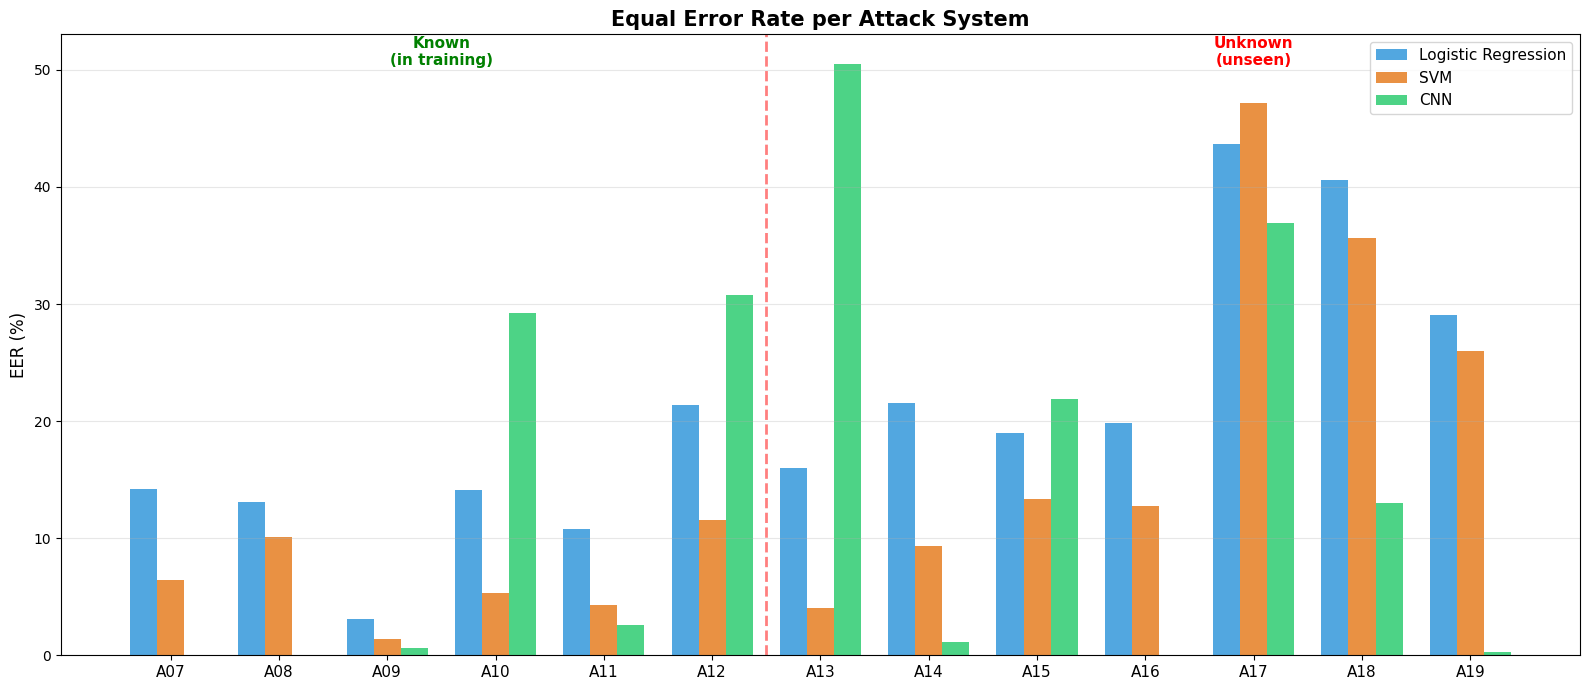

In [83]:
# EER Bar Chart per attack
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(df_results))
w = 0.25

ax.bar(x - w, df_results.LR_EER * 100, w, label='Logistic Regression', alpha=.85, color='#3498db')
ax.bar(x,     df_results.SVM_EER * 100, w, label='SVM', alpha=.85, color='#e67e22')
ax.bar(x + w, df_results.CNN_EER * 100, w, label='CNN', alpha=.85, color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(df_results.System, fontsize=11)
ax.set_ylabel('EER (%)', fontsize=12)
ax.set_title('Equal Error Rate per Attack System', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=.3, axis='y')

# Mark known vs unknown
ax.axvline(x=5.5, color='red', linestyle='--', lw=2, alpha=.5)
ax.text(2.5, ax.get_ylim()[1]*0.95, 'Known\n(in training)', ha='center', fontsize=11, color='green', fontweight='bold')
ax.text(10, ax.get_ylim()[1]*0.95, 'Unknown\n(unseen)', ha='center', fontsize=11, color='red', fontweight='bold')

plt.tight_layout(); plt.show()

---
## AUC Bar Chart per Attack System

Same layout as the EER chart, but showing AUC (Area Under Curve) instead.

### How to read:
- **X-axis:** Attack systems (A07–A19)
- **Y-axis:** AUC score (0 to 1, higher = better detection)
- **Bars near 1.0** = model detects this attack almost perfectly
- **Bars near 0.5** = model is essentially guessing randomly for this attack

### AUC vs EER:
- **AUC** measures overall ranking quality — "does the model assign higher spoof probabilities to actual spoofs?"
- **EER** measures performance at the optimal threshold — "at the best threshold, what's the error rate?"
- Both should tell a consistent story: high AUC ↔ low EER

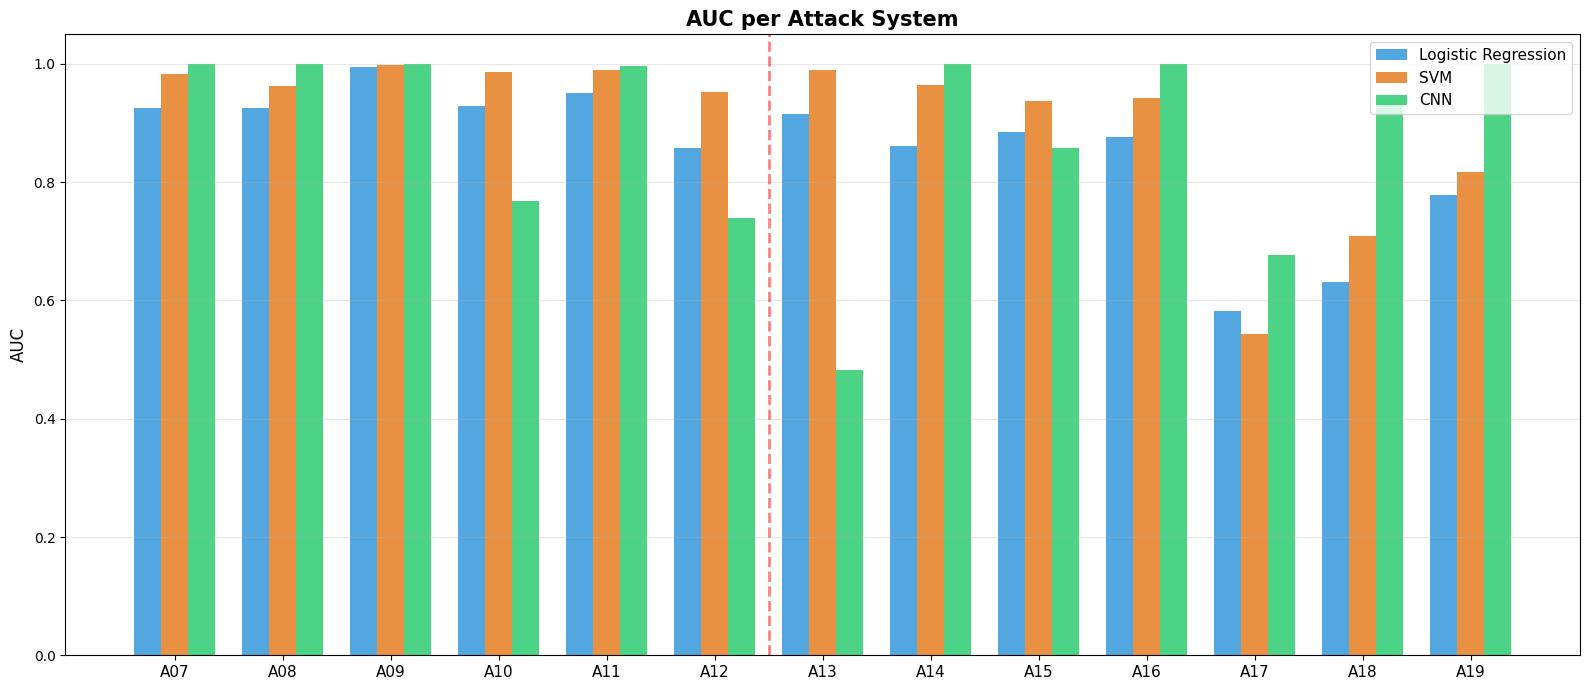

In [84]:
# AUC Bar Chart per attack
fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - w, df_results.LR_AUC, w, label='Logistic Regression', alpha=.85, color='#3498db')
ax.bar(x,     df_results.SVM_AUC, w, label='SVM', alpha=.85, color='#e67e22')
ax.bar(x + w, df_results.CNN_AUC, w, label='CNN', alpha=.85, color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(df_results.System, fontsize=11)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('AUC per Attack System', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=.3, axis='y')
ax.set_ylim(0, 1.05)
ax.axvline(x=5.5, color='red', linestyle='--', lw=2, alpha=.5)
plt.tight_layout(); plt.show()

---
## EER Heatmap: Model × Attack System

A color-coded matrix showing EER (%) for every combination of model and attack system.

### How to read:
- **Rows** = attack systems (A07–A19)
- **Columns** = models (LR, SVM, CNN)
- **Cell value** = EER in percent
- **Green cells** = low EER = good detection
- **Red cells** = high EER = poor detection (security risk)

### Color scale (`RdYlGn_r` = Red-Yellow-Green reversed):
- 🟢 **Dark green** (near 0%) — model detects this attack almost perfectly
- 🟡 **Yellow** (around 15-20%) — moderate detection, some misses
- 🔴 **Dark red** (above 30%) — model fails on this attack, nearly random guessing

### What to look for:
- **Red rows** → attacks that ALL models struggle with (e.g., A17) — most dangerous
- **Green rows** → attacks that are easily detected (e.g., A09) — less concerning
- **Column patterns** → which model is best overall (fewest red cells)

In [ ]:
eer_matrix = df_results[['System','LR_EER','SVM_EER','CNN_EER']].set_index('System') * 100
eer_matrix.columns = ['Logistic Regression', 'SVM', 'CNN']

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(eer_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=.5, annot_kws={'size': 11})
ax.set_title('EER (%) per Attack System × Model\n(Lower = Better)', fontsize=14, fontweight='bold')
ax.set_ylabel('Attack System')
plt.tight_layout(); plt.show()

---
## Attack Difficulty Ranking

Ranks all 13 eval attack systems from hardest to easiest to detect, based on **average EER across all three models**.

### Severity indicators:
- 🔴 **EER > 30%** — Critical: models nearly fail on this attack. This deepfake method would likely bypass detection in a real deployment.
- 🟡 **EER 10–30%** — Moderate: models catch most samples but miss a significant portion. Additional defenses needed.
- 🟢 **EER < 10%** — Well-detected: current models handle this attack effectively.

### Cybersecurity takeaway:
The hardest-to-detect attacks represent the **biggest real-world threat**. If an attacker knows which synthesis method evades detection (e.g., A17), they would use that method exclusively. A robust defense system must either detect ALL attack types or combine multiple detection approaches (ensemble) to cover each model's blind spots.

In [65]:
# Average EER across all models for each attack
df_results['avg_EER'] = df_results[['LR_EER','SVM_EER','CNN_EER']].mean(axis=1)

print('='*50)
print('  ATTACK DIFFICULTY RANKING')
print('  (by average EER across all models)')
print('='*50)
ranked = df_results.sort_values('avg_EER', ascending=False)
for i, (_, r) in enumerate(ranked.iterrows()):
    marker = '🔴' if r.avg_EER > 0.3 else '🟡' if r.avg_EER > 0.1 else '🟢'
    print(f'  {i+1:2d}. {marker} {r.System} — avg EER: {r.avg_EER*100:.1f}% ({r.Known} attack, {r.N_samples} samples)')

print(f'\n  Hardest to detect: {ranked.iloc[0].System} (EER={ranked.iloc[0].avg_EER*100:.1f}%)')
print(f'  Easiest to detect: {ranked.iloc[-1].System} (EER={ranked.iloc[-1].avg_EER*100:.1f}%)')
print(f'\n✅ Per-attack analysis complete!')


  ATTACK DIFFICULTY RANKING
  (by average EER across all models)
   1. 🔴 A17 — avg EER: 44.8% (No attack, 4914 samples)
   2. 🟡 A18 — avg EER: 29.6% (No attack, 4914 samples)
   3. 🟡 A12 — avg EER: 19.0% (No attack, 4914 samples)
   4. 🟡 A19 — avg EER: 18.5% (No attack, 4914 samples)
   5. 🟡 A13 — avg EER: 18.2% (No attack, 4914 samples)
   6. 🟡 A15 — avg EER: 18.0% (No attack, 4914 samples)
   7. 🟡 A10 — avg EER: 14.5% (No attack, 4914 samples)
   8. 🟡 A14 — avg EER: 11.1% (No attack, 4914 samples)
   9. 🟡 A16 — avg EER: 10.9% (No attack, 4914 samples)
  10. 🟢 A11 — avg EER: 8.4% (No attack, 4914 samples)
  11. 🟢 A08 — avg EER: 7.8% (No attack, 4914 samples)
  12. 🟢 A07 — avg EER: 6.9% (No attack, 4914 samples)
  13. 🟢 A09 — avg EER: 1.8% (No attack, 4914 samples)

  Hardest to detect: A17 (EER=44.8%)
  Easiest to detect: A09 (EER=1.8%)

✅ Per-attack analysis complete!


In [136]:
!pip3 install transformers
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

Python(5829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


/Users/kranthk/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


---
## Model 4: Wav2Vec2 Feature Extraction (Meta)

[Wav2Vec2](https://arxiv.org/abs/2006.11477) is a self-supervised speech representation model pre-trained by Meta on **960 hours of unlabeled speech** (LibriSpeech). It learns rich audio representations without needing any labels.

### How it works:
1. **Raw audio** (64,000 samples) goes directly into the model — no MFCCs or spectrograms needed
2. The model's **12 transformer layers** process the audio and produce contextual embeddings
3. Output: a sequence of 768-dim vectors (one per ~20ms frame)
4. We **mean-pool** over time → single 768-dim vector per audio clip

### Why wav2vec2 might outperform hand-crafted features:
- Learned from **960 hours of real speech** — understands speech structure deeply
- 768 dimensions vs 70 hand-crafted features — much richer representation
- Captures patterns that human-designed features might miss

### Key design choices:
| Choice | Reason |
|--------|--------|
| `from_pretrained("facebook/wav2vec2-base")` | Use Meta's pre-trained weights (no fine-tuning) |
| `w2v_model.eval()` | Inference mode — no dropout, no training |
| `torch.no_grad()` | Disable gradients — faster, less memory |
| `w2v_device = 'cpu'` | Wav2vec2 is large (~360MB); keep on CPU to save GPU for CNN |
| `.mean(dim=1)` | Average all time frames into one 768-dim vector |

### Feature comparison:

| Method | Dimensions | Source | Trainable? |
|--------|-----------|--------|-----------|
| Hand-crafted (MFCCs) | 70 | Manually designed formulas | No |
| Mel spectrogram | 128 × 251 | Signal processing | No |
| **Wav2Vec2 embeddings** | **768** | **Learned from 960h of speech** | **Frozen (no fine-tuning)** |

In [139]:
# Load pre-trained wav2vec2 (Meta's base model)
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
w2v_model.eval()
w2v_device = torch.device('cpu')  # wav2vec2 is large, use CPU to save GPU memory
w2v_model.to(w2v_device)

def extract_w2v_features(audio_array):
    """Extract wav2vec2 embeddings from raw audio, return mean-pooled 768-dim vector."""
    inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = w2v_model(inputs.input_values.to(w2v_device))
    # Mean pool over time dimension → (768,) vector
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

# Test
test_audio = load_audio(os.path.join(TRAIN_AUDIO, f'{df_tr.filename.iloc[0]}.flac'))
w2v_feat = extract_w2v_features(test_audio)
print(f'wav2vec2 feature shape: {w2v_feat.shape}')  # Should be (768,)

wav2vec2 feature shape: (768,)



---
## Wav2Vec2 Batch Feature Extraction

Extracts wav2vec2 embeddings for the full training and eval sets.

### Process for each audio file:
.flac file → load_audio() → [64,000 samples] → wav2vec2 model → [768-dim embedding]



### Same stratified sampling as Part 1:
If `MAX_N` is set, the same `random_state=42` sampling is used — ensuring the wav2vec2 features align with the hand-crafted features extracted earlier.

### Output:
- `X_tr_w2v` — shape (N_train, 768) — training embeddings
- `X_ev_w2v` — shape (N_eval, 768) — eval embeddings
- `y_tr_w2v`, `y_ev_w2v` — labels (same as before)

### Time estimate:
Wav2vec2 is slower than MFCC extraction because it runs a 12-layer transformer on each audio clip:

| Dataset | Samples | Approx Time |
|---------|---------|-------------|
| Train (full) | 25,380 | ~30–45 min |
| Eval (full) | 71,237 | ~60–90 min |

Note: We only extract for train and eval (not dev), since we train on train and test on eval.

In [140]:
def extract_w2v_split(df, audio_dir, name, max_n=None):
    print(f'\nExtracting wav2vec2 for {name}')
    if max_n and max_n < len(df):
        db=df[df.label==0]; ds=df[df.label==1]
        nb=min(len(db),max_n//2); ns=min(len(ds),max_n-nb)
        df=pd.concat([db.sample(nb,random_state=42),ds.sample(ns,random_state=42)]).reset_index(drop=True)
    feats, labels = [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=name):
        fp = os.path.join(audio_dir, f'{r.filename}.flac')
        if not os.path.exists(fp): continue
        a = load_audio(fp)
        feats.append(extract_w2v_features(a))
        labels.append(r.label)
    return np.array(feats), np.array(labels)

# This will take a while (~30-60 min for full dataset)
X_tr_w2v, y_tr_w2v = extract_w2v_split(df_tr, TRAIN_AUDIO, 'train', MAX_N)
X_ev_w2v, y_ev_w2v = extract_w2v_split(df_ev, EVAL_AUDIO, 'eval', MAX_N)
print(f'Train: {X_tr_w2v.shape}, Eval: {X_ev_w2v.shape}')


Extracting wav2vec2 for train


train:   0%|          | 0/25380 [00:00<?, ?it/s]


Extracting wav2vec2 for eval


eval:   0%|          | 0/71237 [00:00<?, ?it/s]

Train: (25380, 768), Eval: (71237, 768)


---
## Train Logistic Regression on Wav2Vec2 Embeddings

Same Logistic Regression pipeline as before, but now using **768-dim wav2vec2 embeddings** instead of 70-dim hand-crafted features.

### Pipeline:
1. **StandardScaler** — normalize 768 wav2vec2 features to mean=0, std=1 (fit on train only)
2. **LogisticRegression** — learn 768 weights + bias to classify bonafide vs spoof

### Key question this answers:
> Do wav2vec2's learned speech representations capture deepfake artifacts better than our hand-crafted MFCCs and spectral features?

### What to compare:
| Feature Input | Dimensions | Result variable |
|--------------|-----------|----------------|
| Hand-crafted (MFCCs + spectral) | 70 | `lr_m` |
| **Wav2Vec2 embeddings** | **768** | **`w2v_m`** |

If `w2v_m` has higher recall and lower FN than `lr_m`, it means wav2vec2's pre-trained knowledge of speech generalizes better to unseen attacks than hand-crafted features.


  Wav2Vec2 + LR (Eval)
  Accuracy: 0.9583
                Prec     Rec      F1
  Bonafide    0.7278  0.9523  0.8251
  Spoof       0.9943  0.9590  0.9763
  FP:351 | FN:2619 (missed deepfakes!)
  AUC: 0.9871


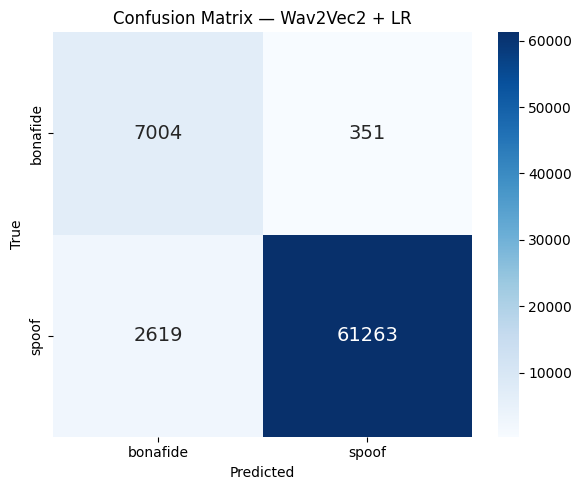

In [141]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

w2v_lr = SkPipeline([('sc', StandardScaler()),
    ('clf', LogisticRegression(C=1, max_iter=1000, random_state=42, class_weight='balanced'))])
w2v_lr.fit(X_tr_w2v, y_tr_w2v)
w2v_pred = w2v_lr.predict(X_ev_w2v)
w2v_prob = w2v_lr.predict_proba(X_ev_w2v)[:,1]
w2v_m = calc_metrics(y_ev_w2v, w2v_pred, w2v_prob)
show(w2v_m, 'Wav2Vec2 + LR (Eval)')
plot_cm(w2v_m, 'Wav2Vec2 + LR')

---
## Train SVM on Wav2Vec2 Embeddings

Same SVM pipeline as before (RBF kernel, balanced class weights), but now on the 768-dim wav2vec2 features.

### Why try SVM on wav2vec2?
SVM with RBF kernel was our best classical model on hand-crafted features. Combining it with wav2vec2's richer 768-dim embeddings could yield even better results — the RBF kernel can find nonlinear boundaries in the higher-dimensional wav2vec2 space.

### ⚠️ Note on training time:
SVM on 768 features is significantly slower than on 70 features, because the RBF kernel computes pairwise distances between all training samples in 768-dim space. Expect ~30-60 minutes for the full training set.


  Wav2Vec2 + SVM (Eval)
  Accuracy: 0.9632
                Prec     Rec      F1
  Bonafide    0.7694  0.9188  0.8375
  Spoof       0.9904  0.9683  0.9792
  FP:597 | FN:2026 (missed deepfakes!)
  AUC: 0.9895


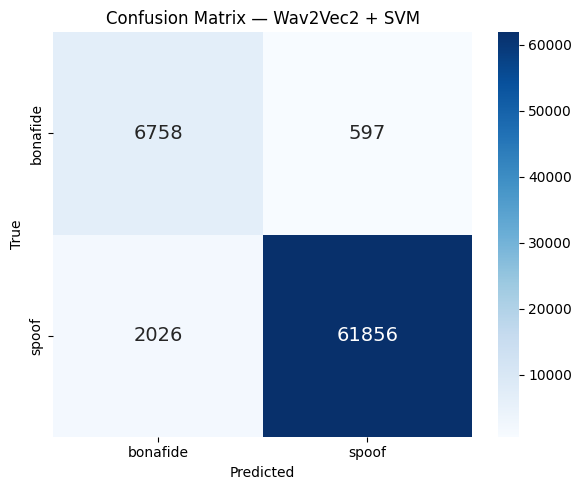

In [142]:
w2v_svm = SkPipeline([('sc', StandardScaler()),
    ('clf', SVC(C=1, kernel='rbf', gamma='scale', random_state=42, class_weight='balanced', probability=True))])
w2v_svm.fit(X_tr_w2v, y_tr_w2v)
w2v_svm_m = calc_metrics(y_ev_w2v, w2v_svm.predict(X_ev_w2v), w2v_svm.predict_proba(X_ev_w2v)[:,1])
show(w2v_svm_m, 'Wav2Vec2 + SVM (Eval)')
plot_cm(w2v_svm_m, 'Wav2Vec2 + SVM')

---
## Per-Attack Analysis: Wav2Vec2 + LR

Same per-attack breakdown as before, but using wav2vec2 embeddings instead of hand-crafted features.

### What this tells us:
- Does wav2vec2's pre-trained speech knowledge help detect the **hard attacks** (like A17) that MFCC-based models struggled with?
- Are there attacks where wav2vec2 is worse than MFCCs? (possible if the attack specifically targets learned representations)

### Compare with earlier results:
The average EER here can be compared directly to the MFCC-based models:
- If wav2vec2 avg EER < SVM avg EER → wav2vec2 embeddings are better features for generalization
- If wav2vec2 avg EER > SVM avg EER → hand-crafted features remain more robust for this task
                                                                              

In [143]:
w2v_probs = w2v_lr.predict_proba(X_ev_w2v)[:,1]

# Get system IDs for eval samples (reuse df_eval from earlier)
systems = df_eval_used['system'].values[:len(y_ev_w2v)]
bon_idx = np.where(y_ev_w2v == 0)[0]
attack_systems = sorted([s for s in np.unique(systems) if s != '-'])

w2v_results = []
for sys_id in attack_systems:
    atk_idx = np.where(systems == sys_id)[0]
    if len(atk_idx) == 0: continue
    idx = np.concatenate([bon_idx, atk_idx])
    y_sub = y_ev_w2v[idx]
    p_sub = w2v_probs[idx]
    try:
        auc_val = compute_auc_score(y_sub, p_sub)
        eer_val = compute_eer(y_sub, p_sub)
    except:
        auc_val, eer_val = np.nan, np.nan
    w2v_results.append({'System': sys_id, 'N_samples': len(atk_idx),
                        'W2V_AUC': auc_val, 'W2V_EER': eer_val})

df_w2v = pd.DataFrame(w2v_results)

print(f'\n{"="*50}')
print(f'  PER-ATTACK: Wav2Vec2 + LR')
print(f'{"="*50}')
print(f'{"System":<8}{"#Spf":>7}  {"AUC":>8}  {"EER":>8}')
print('-'*35)
for _, r in df_w2v.iterrows():
    print(f'{r["System"]:<8}{int(r["N_samples"]):>7}  {r["W2V_AUC"]:>8.4f}  {r["W2V_EER"]:>8.4f}')
print(f'\nAvg EER: {df_w2v["W2V_EER"].mean()*100:.2f}%')
print(f'Avg AUC: {df_w2v["W2V_AUC"].mean():.4f}')


  PER-ATTACK: Wav2Vec2 + LR
System     #Spf       AUC       EER
-----------------------------------
A07        4914    0.9890    0.0358
A08        4914    0.9938    0.0186
A09        4914    0.9951    0.0107
A10        4914    0.9718    0.0752
A11        4914    0.9951    0.0118
A12        4914    0.9937    0.0201
A13        4914    0.9959    0.0083
A14        4914    0.9934    0.0187
A15        4914    0.9766    0.0665
A16        4914    0.9906    0.0322
A17        4914    0.9737    0.0720
A18        4914    0.9941    0.0200
A19        4914    0.9687    0.0786

Avg EER: 3.60%
Avg AUC: 0.9871


In [ ]:
# ============================================================
# Per-Attack EER for Wav2Vec2 + SVM
# ============================================================
w2v_svm_probs = w2v_svm.predict_proba(X_ev_w2v)[:,1]

w2v_svm_results = []
for sys_id in attack_systems:
    atk_idx = np.where(systems == sys_id)[0]
    if len(atk_idx) == 0: continue
    idx = np.concatenate([bon_idx, atk_idx])
    y_sub = y_ev_w2v[idx]
    p_sub = w2v_svm_probs[idx]
    
    auc_val = roc_auc_score(y_sub, p_sub)
    eer_val = compute_eer(y_sub, p_sub)
    w2v_svm_results.append({'System': sys_id, 'W2V_SVM_AUC': auc_val, 'W2V_SVM_EER': eer_val})

df_w2v_svm = pd.DataFrame(w2v_svm_results)

print('=' * 50)
print('  PER-ATTACK: Wav2Vec2 + SVM')
print('=' * 50)
print(f'{"System":<10} {"#Spf":>6} {"AUC":>10} {"EER":>10}')
print('-' * 40)
for _, r in df_w2v_svm.iterrows():
    print(f'{r["System"]:<10} {4914:>6} {r["W2V_SVM_AUC"]:>10.4f} {r["W2V_SVM_EER"]:>10.4f}')
print(f'\nAvg EER: {df_w2v_svm["W2V_SVM_EER"].mean():.4f} ({df_w2v_svm["W2V_SVM_EER"].mean()*100:.2f}%)')
print(f'Avg AUC: {df_w2v_svm["W2V_SVM_AUC"].mean():.4f}')


---
## Combined EER Comparison — All Models × All Attacks

Merges the per-attack EER results from all four model configurations into a single table for direct comparison:

| Column | Feature Input | Classifier |
|--------|--------------|------------|
| `LR_EER` | 70 hand-crafted (MFCCs + spectral) | Logistic Regression |
| `SVM_EER` | 70 hand-crafted (MFCCs + spectral) | SVM (RBF kernel) |
| `CNN_EER` | 128×251 Mel spectrogram | 4-layer CNN |
| `W2V_EER` | 768 wav2vec2 embeddings | Logistic Regression |

### Key comparison:
- **LR_EER vs W2V_EER** — same classifier (LR), different features → measures feature quality
- **SVM_EER vs W2V_EER** — best classical model vs best transfer learning approach
- **Lowest EER per row** → which approach works best for each specific attack


## Combined EER Comparison — All Models × All Attacks

Merges the per-attack EER results from all four model configurations into a single table for direct comparison:

| Column | Feature Input | Classifier |
|--------|--------------|------------|
| `LR_EER` | 70 hand-crafted (MFCCs + spectral) | Logistic Regression |
| `SVM_EER` | 70 hand-crafted (MFCCs + spectral) | SVM (RBF kernel) |
| `CNN_EER` | 128×251 Mel spectrogram | 4-layer CNN |
| `W2V_EER` | 768 wav2vec2 embeddings | Logistic Regression |

### Key comparison:
- **LR_EER vs W2V_EER** — same classifier (LR), different features → measures feature quality
- **SVM_EER vs W2V_EER** — best classical model vs best transfer learning approach
- **Lowest EER per row** → which approach works best for each specific attack


In [144]:
df_combined = df_results.merge(df_w2v[['System','W2V_AUC','W2V_EER']], on='System')
df_combined = df_combined.merge(df_w2v_svm[['System','W2V_SVM_AUC','W2V_SVM_EER']], on='System')
print(df_combined[['System','LR_EER','SVM_EER','CNN_EER','W2V_EER','W2V_SVM_EER']])



   System    LR_EER   SVM_EER   CNN_EER   W2V_EER
0     A07  0.141808  0.063899  0.000000  0.035758
1     A08  0.130647  0.101140  0.000136  0.018627
2     A09  0.030591  0.014140  0.006512  0.010741
3     A10  0.140822  0.052910  0.292023  0.075187
4     A11  0.107546  0.042735  0.025845  0.011803
5     A12  0.213472  0.115568  0.307896  0.020122
6     A13  0.159755  0.039973  0.505088  0.008294
7     A14  0.215507  0.093542  0.011193  0.018722
8     A15  0.189866  0.133243  0.218559  0.066485
9     A16  0.198209  0.127124  0.000204  0.032153
10    A17  0.436711  0.471306  0.369545  0.072039
11    A18  0.405710  0.356492  0.129844  0.019986
12    A19  0.290823  0.259551  0.002849  0.078551
